# Sistema de Predicción de Riesgo y Costo Esperado en Seguros de Auto

---

**Integrantes:**
* Julio César López Becerra
* Mario Nathaniel de la Vega Ramírez
* Francisco Alvarez Aguilera

**Asignatura:**
* Cálculo Numérico y Análisis de Datos con Inteligencia Artificial

<p align="center">
  <img src="https://github.com/FranciscoAlvarezAguilera/popo/blob/main/logo-removebg-preview.png?raw=true" alt="Logo LACD" width="250"/>
</p>

---

*Este notebook contiene el flujo de trabajo completo que explora y modela los costos y beneficios de una compañía aseguradora enfocada al ramo del seguro de autos.*

---

## Índice de Contenidos

* [0. Importación de librerías necesarias](#0-importación-de-librerías-necesarias)
* [1. Carga de la Base de Datos](#1-carga-de-la-base-de-datos)
  * [1.1 Interacción, Transformación y Discretización de Variables](#11-interacción-transformación-y-discretización-de-variables)
  * [1.2 Selección de Variables Numéricas y Categóricas](#12-selección-de-variables-numéricas-y-categóricas)
* [2. Análisis Exploratorio de Datos (EDA)](#2-análisis-exploratorio-de-datos-eda)
  * [2.1 Dimensiones del Dataset](#21-dimensiones-del-dataset)
  * [2.2 Tipos de Variables y Valores Faltantes](#22-tipos-de-variables-y-valores-faltantes)
  * [2.3 Balance de Clases](#23-balance-de-clases)
  * [2.4 Análisis de Correlación](#24-análisis-de-correlación)
  * [2.5 Análisis de Distribuciones](#25-análisis-de-distribuciones)
* [3. Preprocesamiento de Datos](#3-preprocesamiento-de-datos)
  * [3.1 División de Datos](#31-división-de-datos)
  * [3.2 Análisis y Detección de Valores Atípicos (Outliers)](#32-análisis-y-detección-de-valores-atípicos-outliers)
  * [3.3 Escalado mediante MinMaxScaler (Demostrativo)](#33-escalado-mediante-minmaxscaler-demostrativo)
  * [3.4 Imputación de Variables Numéricas (Demostrativo)](#34-imputación-de-variables-numéricas-demostrativo)
  * [3.5 Desarrollo de la Clase de Preprocesamiento (`preprocessing.py`)](#35-desarrollo-de-la-clase-de-preprocesamiento-preprocessingpy)
  * [3.6 Clasificación de Variables](#36-clasificación-de-variables)
  * [3.7 Preprocesamiento Unificado (`ColumnTransformer` y `Pipeline`)](#37-preprocesamiento-unificado-columntransformer-y-pipeline)
* [4. Entrenamiento y Optimización](#4-entrenamiento-y-optimización)
  * [4.1 Generación de Particiones para Entrenamiento](#41-generación-de-particiones-para-entrenamiento)
  * [4.2 Entrenamiento de Modelos de Regresión](#42-entrenamiento-de-modelos-de-regresión)
    * [4.2.1 Significado de las métricas:](#421-significado-de-las-métricas)
    * [4.2.2 Evaluación del Desempeño del Mejor Estimador de Regresión](#422-evaluación-del-desempeño-del-mejor-estimador-de-regresión)
  * [4.3 Entrenamiento de Modelos de Clasificación](#43-entrenamiento-de-modelos-de-clasificación)
  * [4.4 Calibración del Umbral Óptimo de Decisión](#44-calibración-del-umbral-óptimo-de-decisión)
  * [4.5 Reducción de Dimensionalidad mediante PCA](#45-reducción-de-dimensionalidad-mediante-pca)
  * [4.6 Evaluación de Rendimiento General (Conjunto de Prueba)](#46-evaluación-de-rendimiento-general-conjunto-de-prueba)
* [5. Interpretación de Parámetros e Importancia de Atributos](#5-interpretación-de-parámetros-e-importancia-de-atributos)
  * [5.1 Importancia de Atributos en Random Forest (Regresión)](#51-importancia-de-atributos-en-random-forest-regresión)
    * [5.1.1 Análisis e interpretación de las variables principales](#511-análisis-e-interpretación-de-las-variables-principales)
  * [5.2 Importancia de Atributos en Random Forest (Clasificación)](#52-importancia-de-atributos-en-random-forest-clasificación)
    * [5.2.1 Análisis e interpretación de las variables principales  ("Alto Riesgo" - Random Forest Classifier)](#521-análisis-e-interpretación-de-las-variables-principales--alto-riesgo---random-forest-classifier)
* [6. Serialización y Almacenamiento de Modelos (joblib)](#6-serialización-y-almacenamiento-de-modelos-joblib)


## 0. Importación de librerías necesarias

In [1]:
import matplotlib.pyplot as plt # Libreria de gráficos
import joblib # joblib.dump() guardará los modelos entrenados en un archivo
import json # Libreria para manejo de datos en formatos ligeros
import sys # Permite trabajar directamente con el intérprete y el entorno de ejecución

import seaborn as sns # Graficas mas sofisticadas 
import plotly.express as px # Más graficos interactivos y complejos

import scipy.stats as stats # Funciones estadísticas de SciPy
import pandas as pd # Manipulación y análisis de datos
import numpy as np # Operaciones numéricas
from pathlib import Path # Manejo de rutas de archivos 
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder # Escalado y codificación de variables (preprocesamiento)
from sklearn.impute import SimpleImputer, KNNImputer # Imputación
from sklearn.model_selection import train_test_split # Dividir datos en entrenamiento y prueba
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor # Árboles de decisión (clasificación y regresión)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor # Métodos de ensamblado
from sklearn.decomposition import PCA # Reducción de dimensionalidad 
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso # Modelos de regresión, clasificación y sus métricas 
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error, mean_squared_error, r2_score ,precision_score, recall_score, ConfusionMatrixDisplay, average_precision_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline # Pipeline sirve para encadenar pasos de preprocesamiento
from sklearn.dummy import DummyClassifier, DummyRegressor # Usamos Dummies como una linea base
from sklearn.compose import ColumnTransformer # Transformar columnas 
from sklearn.utils.class_weight import compute_sample_weight #Pesos de clase para datos desbalanceados

from ipywidgets import interact, Dropdown, IntSlider, Checkbox, fixed # Son Widgets interactivos en Jupyter

# Aquí establecemos las carpetas pertinentes para el proyecto
RANDOM_STATE = 42
BASE_DIR = Path.cwd().parent 
DATA_PATH = BASE_DIR / "data" / "seguro_auto_actuarial.csv"
MODELS_DIR = BASE_DIR / "models"
OUTPUTS_DIR = BASE_DIR / "outputs"
UTILS_DIR = BASE_DIR / "utils"
ASSETS_DIR = BASE_DIR / "assets" / "imagenes_ejemplo_vehiculos"

# Creamos las carpetas si no existen
for carpeta in [MODELS_DIR, OUTPUTS_DIR, UTILS_DIR, ASSETS_DIR]:
    carpeta.mkdir(parents = True, exist_ok = True)
print("Raíz del proyecto:", BASE_DIR) # Mostramos donde está el proyecto



Raíz del proyecto: c:\Users\PC\OneDrive\Documentos\GitHub\proyecto_seguro_actuarial


## 1. Carga de la Base de Datos

In [2]:
df = pd.read_csv(DATA_PATH)
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df.head()

,poliza_id,edad_conductor,sexo,estado_civil,nivel_estudios,ocupacion,zona_residencia,region,antiguedad_cliente_anios,ingreso_mensual_mxn,...,canal_venta,tiene_gps,asistencia_vial,mantenimiento_al_dia,dias_hasta_renovacion,puntaje_riesgo_zona,numero_siniestros_12m,costo_esperado_anual_mxn,riesgo_alto,clase_costo
0,POL-00001,46,Femenino,Soltero,Posgrado,Independiente,Urbana,Sur,9.4,7038.0,...,Agente,Si,Si,Si,170,74.7,0,3321,0,Bajo
1,POL-00002,38,Masculino,Casado,Licenciatura,Estudiante,Suburbana,Centro,0.9,19655.0,...,Agente,No,No,Si,100,57.4,0,7196,0,Medio
2,POL-00003,48,Masculino,Divorciado,Licenciatura,Empleado,Urbana,Centro,0.1,16140.0,...,Agente,No,No,Si,69,71.3,0,2046,0,Bajo
3,POL-00004,60,Femenino,Divorciado,Licenciatura,Empleado,Urbana,Sur,0.1,14954.0,...,Online,Si,No,No,173,83.4,0,1379,0,Bajo
4,POL-00005,37,Femenino,Soltero,Preparatoria,Empleado,Urbana,Centro,3.9,27192.0,...,Agente,Si,Si,No,188,73.6,1,11787,1,Alto


Marcaremos la variable `poliza_id` como índice del conjunto de datos para evitar su uso accidental como variable predictora en los modelos.

In [3]:
df = df.set_index("poliza_id")
df.index = df.index.str.replace('POL-', '').astype(int)
df.head()

,edad_conductor,sexo,estado_civil,nivel_estudios,ocupacion,zona_residencia,region,antiguedad_cliente_anios,ingreso_mensual_mxn,score_crediticio,...,canal_venta,tiene_gps,asistencia_vial,mantenimiento_al_dia,dias_hasta_renovacion,puntaje_riesgo_zona,numero_siniestros_12m,costo_esperado_anual_mxn,riesgo_alto,clase_costo
poliza_id,,,,,,,,,,,,,,,,,,,,,
1,46,Femenino,Soltero,Posgrado,Independiente,Urbana,Sur,9.4,7038.0,613.0,...,Agente,Si,Si,Si,170,74.7,0,3321,0,Bajo
2,38,Masculino,Casado,Licenciatura,Estudiante,Suburbana,Centro,0.9,19655.0,565.0,...,Agente,No,No,Si,100,57.4,0,7196,0,Medio
3,48,Masculino,Divorciado,Licenciatura,Empleado,Urbana,Centro,0.1,16140.0,641.0,...,Agente,No,No,Si,69,71.3,0,2046,0,Bajo
4,60,Femenino,Divorciado,Licenciatura,Empleado,Urbana,Sur,0.1,14954.0,570.0,...,Online,Si,No,No,173,83.4,0,1379,0,Bajo
5,37,Femenino,Soltero,Preparatoria,Empleado,Urbana,Centro,3.9,27192.0,586.0,...,Agente,Si,Si,No,188,73.6,1,11787,1,Alto


### 1.1 Interacción, Transformación y Discretización de Variables

Se generan nuevas variables a través de transformaciones logarítmicas (tales como `log_ingreso_mensual_mxn` y `log_suma_asegurada`) y se discretiza la variable numérica `edad_conductor` para definir intervalos en `grupo_edad_conductor`.

Estas transformaciones representan prácticas estándar en la preparación de datos para modelos actuariales de riesgo y tarificación en seguros de automóviles, ya que mejoran el desempeño predictivo y la estabilidad numérica de los algoritmos. Por ejemplo, en el caso de la variable `numero_siniestros_12m`, se convierte la información cuantitativa en una variable categórica de dos niveles, útil cuando la ocurrencia o ausencia de siniestros influye de forma no lineal en la variable objetivo.

In [4]:
# Buenas practicas de programación, evitamos modificar la base de datos original.
df_muestreo = df.copy()
# Generación de variables por interacción y transformación 
df_muestreo['km_totales'] = df_muestreo['km_anuales'] * df_muestreo['edad_vehiculo_anios']
df_muestreo['log_km_totales'] = np.log1p(df_muestreo['km_totales'])
df_muestreo['log_ingreso_mensual_mxn'] = np.log1p(df_muestreo['ingreso_mensual_mxn'])
df_muestreo['log_suma_asegurada'] = np.log1p(df_muestreo['suma_asegurada_mxn'])
# Codificación binaria 
df_muestreo['siniestros_en_12m'] = np.where(df_muestreo['numero_siniestros_12m'] > 0, 'Si', 'No')
df_muestreo['prima_mayor_a_mediana'] = np.where(df_muestreo['prima_mensual_mxn'] > df_muestreo['prima_mensual_mxn'].median(), 'Si', 'No')
# Discretización de una variable numerica por rango
df_muestreo['grupo_edad_conductor'] = pd.cut(
            df_muestreo['edad_conductor'],
            bins=[17, 25, 35, 50, 65, np.inf],
            labels=['18-25', '26-35', '36-50', '51-65', '66+'],
            include_lowest=True
        ).astype(str)

### 1.2 Selección de Variables Numéricas y Categóricas

* **Variables Numéricas (Cuantitativas):** Expresan magnitudes exactas y permiten calcular promedios, sumas y otras operaciones aritméticas. Se clasifican en continuas y discretas.
* **Variables Categóricas (Cualitativas):** Agrupan a las observaciones en categorías o etiquetas descriptivas. Se subdividen en nominales y ordinales.

In [5]:
# Agrupamos columnas por su tipo de dato (numérico vs. categórico) y las metemos en el diccionario "tipos{}"
tipos = {}

for i in df_muestreo.dtypes.unique():
    tipos_key = str(i)
    columnas = df_muestreo.select_dtypes(include = [i]).columns.tolist()
    tipos[tipos_key] = columnas

numerico = []

categorica = []

for j in tipos.keys():
   for i in tipos[j]:
      if(len(df_muestreo[i].value_counts().index.to_list()) < 10):  ## cuantos valores unicos tiene
         categorica.append(i)

      else:
         numerico.append(i)

# reclasificamos estas variables por su naturaleza 
categorica.remove('historial_siniestros_3_anios')
categorica.remove('numero_siniestros_12m')

numerico.append('historial_siniestros_3_anios')
numerico.append('numero_siniestros_12m')



## 2. Análisis Exploratorio de Datos (EDA)

**Objetivo:** Identificar las dimensiones del conjunto de datos, tipos de variables, valores faltantes, distribuciones empíricas, correlaciones y el balance de clases.

---

### 2.1 Dimensiones del Dataset

In [6]:
print("Dimensiones de la base de datos", df.shape)

Dimensiones de la base de datos (1500, 30)


### 2.2 Tipos de Variables y Valores Faltantes

Se genera una tabla descriptiva con los tipos de datos, cantidad y porcentaje de valores faltantes, y cantidad de valores únicos por cada columna de interés.

In [7]:
analisis = pd.DataFrame({
    "Tipo de dato": df.dtypes,
    "Valores faltantes": df.isnull().sum(),
    "Porcentaje": 100 * df.isnull().sum() / len(df),
    "Valores unicos": df.nunique()
}).sort_values(["Porcentaje"], ascending = False)
analisis

,Tipo de dato,Valores faltantes,Porcentaje,Valores unicos
ingreso_mensual_mxn,float64,106,7.066667,1358
score_crediticio,float64,85,5.666667,332
ocupacion,str,81,5.400000,6
puntaje_riesgo_zona,float64,53,3.533333,486
mantenimiento_al_dia,str,46,3.066667,2
segmento_marca,str,44,2.933333,3
zona_residencia,str,0,0.000000,3
nivel_estudios,str,0,0.000000,4
antiguedad_cliente_anios,float64,0,0.000000,166
region,str,0,0.000000,5


Se genera un gráfico para mejorar la visualización y distribución de los datos faltantes en las variables.

,Tipo de dato,Valores faltantes,Porcentaje,Valores unicos
ingreso_mensual_mxn,float64,106,7.066667,1358
score_crediticio,float64,85,5.666667,332
ocupacion,str,81,5.400000,6
puntaje_riesgo_zona,float64,53,3.533333,486
mantenimiento_al_dia,str,46,3.066667,2
segmento_marca,str,44,2.933333,3


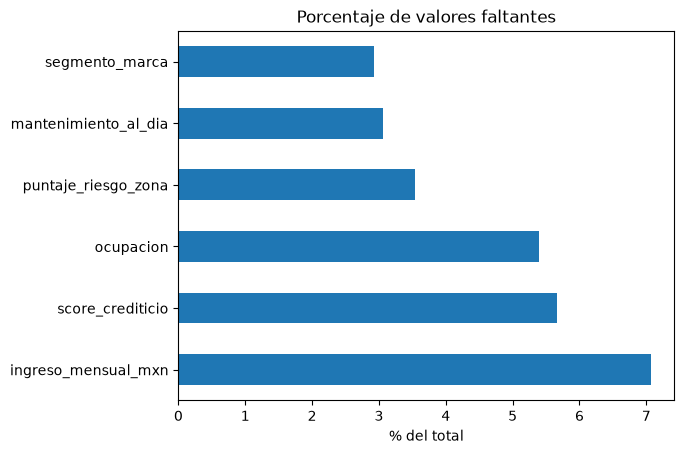

In [8]:
variables_con_faltante = analisis.loc[analisis["Valores faltantes"] > 0]
display(variables_con_faltante)

variables_con_faltante["Porcentaje"].plot(kind = "barh")
plt.title("Porcentaje de valores faltantes")
plt.xlabel("% del total")
plt.show()

Se observa que la proporción de valores faltantes es sumamente baja en todo el conjunto de datos. La variable con mayor número de datos nulos es `ingreso_mensual_mxn`.

### 2.3 Balance de Clases

Con base en los requerimientos metodológicos del proyecto, se analiza la proporción y balanceo de la variable objetivo `riesgo_alto`.

In [9]:
## Se crea una funcion para poder pasarla a utils

# nbins es el número de intervalos que va a hacer en el continuo de los valores numericos

def histograma_plotly(data, variable_num, variable_cat, nbins = 40, por_cateogria = True):
    # Generamos el histograma con el marginal tipo box, pues esto hace posible ver los outliers mediante el método de IQR
    
    # Si queremos diferenciarlos por cateogrías
    if por_cateogria:
        fig = px.histogram(
            data,           
            x=variable_num, 
            color=variable_cat, # Diferenciar los datos por color mediante su categoría
            marginal="box",     # Agrega boxplot, o diagrama de caja y bigotes para ver el IQR  y por ende los outliers         
            barmode="overlay",  # Hace que se hagan menos opacos los histogrammas para verlos mejor         
            nbins= nbins,                     
            title=f"Distribución de {variable_num.replace('_', ' ').title()} por {variable_cat.replace('_', ' ').title()}",
            template="plotly_white",      # Un fondo blanco limpio y estético
            color_discrete_sequence=px.colors.qualitative.Safe # Paleta de colores moderna
        )

    # O bien, ver la distribución de la muestra para cada categoría numerica
    else: 
         fig = px.histogram(
            data, 
            x=variable_num, 
         
            marginal="box",               
            barmode="overlay",            
            nbins= nbins,                     
            title=f"Distribución de {variable_num.replace('_', ' ').title()}",
            template="plotly_white",      # Un fondo blanco limpio y estético
            color_discrete_sequence=px.colors.qualitative.Safe # Paleta de colores moderna       
        )
         
    fig.update_xaxes(title_text = variable_num.replace('_', ' ').title())
    fig.update_yaxes(title_text = 'Recuento')

    fig.update_layout(
    legend_title_text = variable_cat.replace('_', ' ').title(), 
    height=1000,
    title_font_size=18,
    hovermode="x unified"  # Agrupa el tooltip para ver todas las categorías juntas al pasar el mouse
    )
    # fig.show()
    return fig
    
def Balance_de_Clases(data, categoria):
    # Contamos cuántas veces aparece cada valor de la categoría y lo convertimos a tabla
    Conteo = data[categoria].value_counts().reset_index()
    Conteo.columns = ['Categoría', 'Cantidad']
    Conteo['Proporcion'] = Conteo['Cantidad']/Conteo['Cantidad'].sum().round(4)

    # Creamos una barra con Plotly para visualizar el balance de clases
    fig = px.bar(
        Conteo, 
        x = 'Categoría',
        y = 'Cantidad',
        text = Conteo['Proporcion'],
        title=f"Análisis de Balance de Clases de: {categoria.replace('_', ' ').title()}",
        template="plotly_white",
        color='Categoría',
        color_discrete_sequence=px.colors.qualitative.Pastel
    )

    fig.update_traces(textposition='outside') # Coloca el texto del % fuera de la barra
    fig.update_layout(
        yaxis_title="Número de Registros",
        xaxis_title=categoria.replace('_', ' ').title()
    )
    #fig.show()
    return fig

In [10]:
interact(
    Balance_de_Clases, 
    data = fixed(df_muestreo),
    categoria=Dropdown(options= categorica, value='riesgo_alto', description='Variable:')
)

interactive(children=(Dropdown(description='Variable:', index=1, options=('deducible_pct', 'riesgo_alto', 'sex…

<function __main__.Balance_de_Clases(data, categoria)>

El análisis preliminar revela que los perfiles clasificados como riesgo alto representan aproximadamente el 15% de la cartera. Este desbalance es un aspecto crítico para el diseño de las estrategias predictivas:

* Un modelo ingenuo que prediga por defecto la clase mayoritaria obtendría una exactitud (*accuracy*) cercana al 85%, pero fallaría por completo al identificar los siniestros de riesgo alto (sensibilidad/*recall* igual a cero).
* Por consiguiente, se priorizará el uso de métricas robustas frente al desbalance de clases, tales como el **F1-score** y el **AUC-ROC**, para la evaluación de los modelos.

### 2.4 Análisis de Correlación

In [11]:
# Seleccionamos unicamente las variables numericas para poder calcular la mariz de correaciones.
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
columnas_numericas = columnas_numericas.drop(["riesgo_alto"])
correlaciones = df[columnas_numericas].corr()

<Axes: >

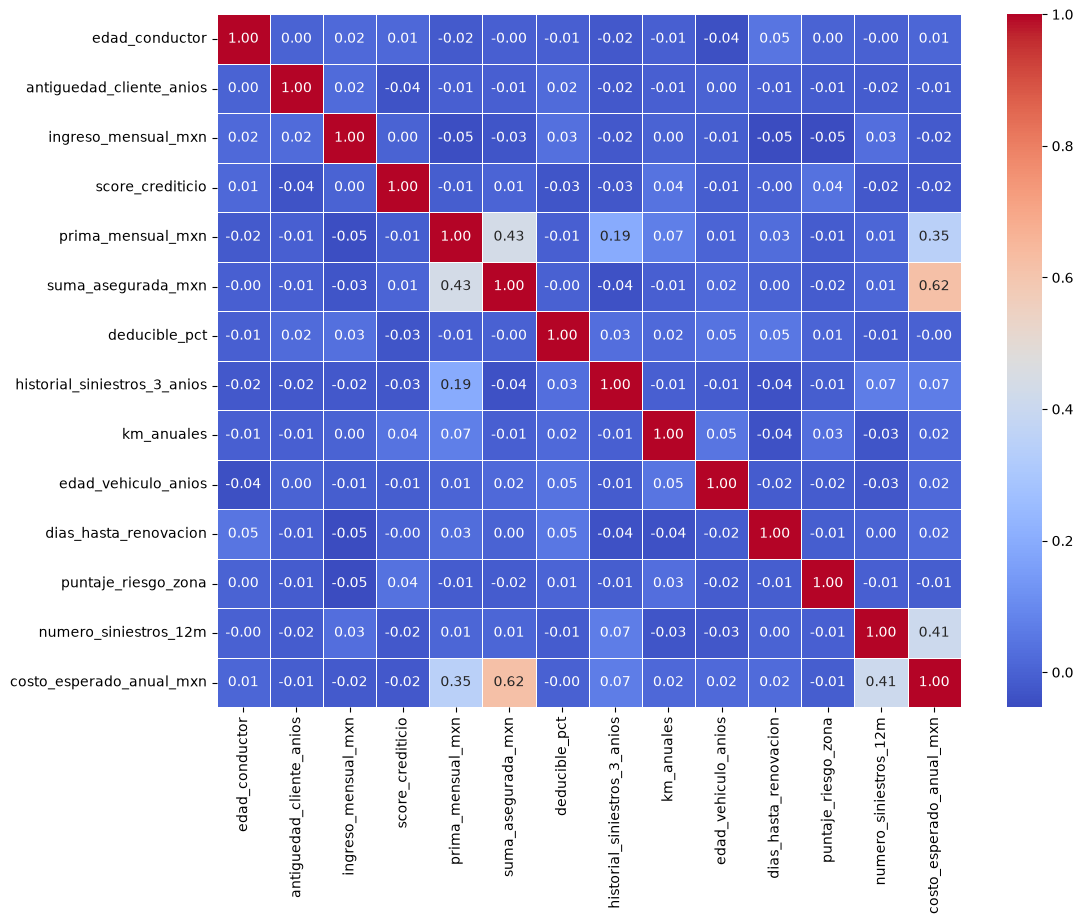

In [12]:

plt.figure(figsize = (12,9))
sns.heatmap(
    correlaciones,
    annot = True,
    cmap="coolwarm",  
    fmt=".2f",  
    vmax=1,  
    linewidths=0.5
    )

Al evaluar la matriz de correlación se observa que la gran mayoría de las variables muestran coeficientes cercanos a cero, indicando una alta independencia lineal que mitiga el riesgo de redundancia en los modelos predictivos.

Las relaciones lineales más significativas son:
* **`suma_asegurada_mxn` - `costo_esperado_anual_mxn` (0.62):** Correlación positiva fuerte, consistente con la teoría actuarial donde a mayor exposición asegurada corresponde un mayor costo potencial de siniestro.
* **`prima_mensual_mxn` - `suma_asegurada_mxn` (0.43):** Correlación positiva moderada, que refleja las bases de tarificación comercial de la aseguradora.
* **`historial_siniestros_3_anios` - `prima_mensual_mxn` (0.19):** Correlación positiva débil pero relevante, indicativa de un ajuste de tarifas basado en la siniestralidad previa del cliente.

### 2.5 Análisis de Distribuciones

Dada la cantidad de atributos en el conjunto de datos, se analizan únicamente las distribuciones empíricas de las variables más representativas para el negocio.

In [13]:
interact(
    histograma_plotly,
    data = fixed(df_muestreo),
    variable_num = Dropdown(options = numerico,value = 'costo_esperado_anual_mxn', description = 'Numérica'),
    variable_cat = Dropdown(options = categorica, value = 'zona_residencia', description = 'Categoría:'),
    nbins = IntSlider(min = 10, max = 250, step = 1, value = 40, description = 'Intervalos: '),
    por_cateogria = Checkbox(description = 'Categorias', value = True)
)

interactive(children=(Dropdown(description='Numérica', index=2, options=('edad_conductor', 'dias_hasta_renovac…

<function __main__.histograma_plotly(data, variable_num, variable_cat, nbins=40, por_cateogria=True)>

En primer lugar, los diagramas de caja (*box plots*) revelan que la distribución del costo esperado anual se comporta de manera homogénea independientemente de la zona de residencia del asegurado (urbana, suburbana o rural).

Por otra parte, se identifica un aspecto relevante de negocio:
* Una fracción considerable de la cartera paga primas mínimas.
* Sin embargo, existe una discrepancia entre la prima cobrada y el subgrupo de riesgo alto (15%). Algunos clientes presentan un perfil de riesgo elevado que no está adecuadamente reflejado en sus primas mensuales.
* Los valores atípicos (*outliers*) de costo que se extienden en la cola derecha corresponden a siniestros de severidad donde la aseguradora incurre en desviaciones significativas. Esto subraya la necesidad de implementar un modelo predictivo capaz de identificar oportunamente el riesgo real para ajustar los esquemas de tarificación.

## 3. Preprocesamiento de Datos

### 3.1 División de Datos

Se realiza la partición del dataset antes de aplicar cualquier método de normalización, imputación o escalamiento, mitigando la **fuga de datos** (*data leakage*).

**Metodología de división:**
* Se utiliza un esquema de partición estratificado respecto a la clase de riesgo para preservar la representatividad en todos los subconjuntos.
* Para corregir sesgos metodológicos de ajuste e hiperparametrización observados en pruebas previas, se estructuran tres conjuntos mutuamente excluyentes:
  * **Entrenamiento (60%):** Utilizado para el ajuste de los parámetros del modelo.
  * **Validación (20%):** Destinado a la comparación de modelos y sintonización de hiperparámetros.
  * **Prueba / Test (20%):** Reservado únicamente para la evaluación final del rendimiento general del modelo.

Se define la función auxiliar `Outlier_descriptive()` para analizar valores atípicos en columnas numéricas. Esta función genera estadísticas de dispersión útiles basadas en criterios de Tukey (rango intercuartílico), límites a tres desviaciones estándar ($3\sigma$), y percentiles extremos (como el percentil 99.9).

In [14]:
def Outlier_descriptive(data, columna, describe = False):

    n = data[columna].count()

    p995 = data[columna].quantile(0.995)
    p999 = data[columna].quantile(0.999)

    r = data[columna].std()
    mean =  data[columna].mean()

    desvest_3 = mean + 3*r

    q3 = data[columna].quantile(0.75) 
    q1 = data[columna].quantile(0.25)
    iqr =  q3 - q1
    
    uper_fence = q3 + (1.5 *iqr)
    lower_fence = q1 - (1.5 *iqr)
    ## Si gamma distribuida
    alpha = (mean / r)** 2
    beta = (r **2)/ mean


    # Calcular la probabilidad acumulada de la cola derecha
    prob_extremo = 1 - stats.gamma.cdf(desvest_3, a=alpha, scale=beta)

    if describe:
      print(f"Probabilidad exacta de un evento > 3 sigma si es gamma: {prob_extremo:.5f}, \n",
            'Si son', n, 'observaciones, podriamos esperar hasta', prob_extremo*n, 'observaciones en la cola\n')


      print(
      'Numero de observaciones despues del percentil 99.5 : ', data[data[columna] > p995][columna].count(),
      'Numero de observaciones despues del percentil 99.9 : ', data[data[columna] > p999][columna].count(),
      '\nNumero de observaciones despues de media mas 3 desv. est. : ', data[data[columna] > desvest_3 ][columna].count(),
      '\nNumero de observaciones despues del 150% del IQR (Tukey): ', data[data[columna] > uper_fence][columna].count()
      )
    return {'Percentil 99.5': p995,
            'Percentil 99.9': p999,
            'Media +3 desv. est.': desvest_3,
            'Upperfence':uper_fence,
            'LowerFence':lower_fence


            }

In [15]:
## Eliminación de Outliers


df['log_suma_asegurada'] = np.log1p(df['suma_asegurada_mxn'])
df['log_costo'] = np.log(df['costo_esperado_anual_mxn'])
df['ratio_costo_prima'] = df['costo_esperado_anual_mxn']/df['prima_mensual_mxn']


df = df[
    (df['log_costo'] < Outlier_descriptive(data = df, columna='log_costo')['Percentil 99.5']) 
    
    &(df['log_suma_asegurada'] < Outlier_descriptive(data = df, columna='log_suma_asegurada')['Percentil 99.5'])

    &(df['ratio_costo_prima'] < Outlier_descriptive(data = df, columna='ratio_costo_prima')['Percentil 99.5'])
    ]

df = df.drop(['ratio_costo_prima', 'log_suma_asegurada', 'log_costo'], axis = 1)

df_muestreo['log_suma_asegurada'] = np.log1p(df_muestreo['suma_asegurada_mxn'])
df_muestreo['log_costo'] = np.log(df_muestreo['costo_esperado_anual_mxn'])
df_muestreo['ratio_costo_prima'] = df_muestreo['costo_esperado_anual_mxn']/df_muestreo['prima_mensual_mxn']


df_muestreo = df_muestreo[
    (df_muestreo['log_costo'] < Outlier_descriptive(data = df_muestreo, columna='log_costo')['Percentil 99.5']) 
    
    &(df_muestreo['log_suma_asegurada'] < Outlier_descriptive(data = df_muestreo, columna='log_suma_asegurada')['Percentil 99.5'])

    &(df_muestreo['ratio_costo_prima'] < Outlier_descriptive(data = df_muestreo, columna='ratio_costo_prima')['Percentil 99.5'])
    ]

df_muestreo = df_muestreo.drop(['ratio_costo_prima', 'log_suma_asegurada', 'log_costo'], axis = 1)

df.count()

edad_conductor                  1480
sexo                            1480
estado_civil                    1480
nivel_estudios                  1480
ocupacion                       1402
zona_residencia                 1480
region                          1480
antiguedad_cliente_anios        1480
ingreso_mensual_mxn             1374
score_crediticio                1395
prima_mensual_mxn               1480
suma_asegurada_mxn              1480
deducible_pct                   1480
historial_siniestros_3_anios    1480
km_anuales                      1480
edad_vehiculo_anios             1480
tipo_vehiculo                   1480
uso_vehiculo                    1480
segmento_marca                  1436
metodo_pago                     1480
canal_venta                     1480
tiene_gps                       1480
asistencia_vial                 1480
mantenimiento_al_dia            1434
dias_hasta_renovacion           1480
puntaje_riesgo_zona             1427
numero_siniestros_12m           1480
c

In [16]:
interact(
    histograma_plotly,
    data = fixed(df_muestreo),
    variable_num = Dropdown(options = numerico,value = 'costo_esperado_anual_mxn', description = 'Numérica'),
    variable_cat = Dropdown(options = categorica, value = 'zona_residencia', description = 'Categoría:'),
    nbins = IntSlider(min = 10, max = 250, step = 1, value = 40, description = 'Intervalos: '),
    por_cateogria = Checkbox(description = 'Categorias', value = True)
);

interactive(children=(Dropdown(description='Numérica', index=2, options=('edad_conductor', 'dias_hasta_renovac…

Se realiza la partición del dataset en los tres conjuntos planificados. En primer lugar, se aísla el 20% del total para el conjunto de prueba. Del 80% restante, se destina el 25% para el conjunto de validación.

La partición se realiza de forma estratificada con respecto a la variable `riesgo_alto` con el fin de evitar el desbalance extremo de clases en cualquiera de las divisiones. Finalmente, se verifican las dimensiones resultantes.

In [17]:
id_train_val, id_test = train_test_split(
    df.index,
    test_size = 0.20,
    random_state = RANDOM_STATE,
    stratify = df["riesgo_alto"]
)

id_train, id_val = train_test_split(
    id_train_val,
    test_size = 0.25,
    random_state = RANDOM_STATE,
    stratify = df.loc[id_train_val, "riesgo_alto"]
)

print("Elementos train:",len(id_train))
print("Elementos val:",len(id_val))
print("Elementos test:",len(id_test))

Elementos train: 888
Elementos val: 296
Elementos test: 296


### 3.2 Análisis y Detección de Valores Atípicos (Outliers)

In [18]:
 #LIsta donde vamos guardanado los resultados
outliers = []

for col in columnas_numericas:
    

    ## Método Tukey: sacamos los límites con el rango intercuartílico (IQR)
    lim_inf = Outlier_descriptive(df, col)['LowerFence']
    lim_sup = Outlier_descriptive(df, col)['Upperfence']

    ## Método de 3 desviaciones estándar (solo por la derecha)
    sd3 = Outlier_descriptive(df,col)['Media +3 desv. est.']


    # Filtramos los outliers con Tukey (los que caen fuera de los límites)
    df_outliers1 = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
    # Filtramos outliers con el criterio de 3 desv. est. (solo los de arriba)
    df_outliers2 = df[ ( df[col] > sd3 )]

    # Calculamos los porcentajes que representan esas aberraciones 
    porcentaje1 = 100 * len(df_outliers1) / len(df)
    porcentaje2 = 100 * len(df_outliers2) / len(df)
    
    # Lo metemos a un diccionario
    outliers.append({
        "Columna": col,
        "Cantidad de outliers(Tukey)": len(df_outliers1),
        "Porcentaje(Tukey)": round(porcentaje1, 2),
        "Cantidad de outliers(Media + 3 desv. est)": len(df_outliers2),
        "Porcentaje(Media + 3 desv. est)": round(porcentaje2, 2)
    })
# Lo hacemos dataframe
df_outliers = pd.DataFrame(outliers)
# Lo ordenamos de menor a mayor (podria ser al reves eh)
df_outliers_ordenado = df_outliers.sort_values(by="Porcentaje(Tukey)", ascending=True)
df_outliers_ordenado

,Columna,Cantidad de outliers(Tukey),Porcentaje(Tukey),Cantidad de outliers(Media + 3 desv. est),Porcentaje(Media + 3 desv. est)
6,deducible_pct,0,0.00,0,0.00
10,dias_hasta_renovacion,0,0.00,0,0.00
11,puntaje_riesgo_zona,1,0.07,0,0.00
0,edad_conductor,3,0.20,0,0.00
8,km_anuales,5,0.34,2,0.14
3,score_crediticio,12,0.81,0,0.00
7,historial_siniestros_3_anios,14,0.95,14,0.95
9,edad_vehiculo_anios,34,2.30,17,1.15
2,ingreso_mensual_mxn,63,4.26,13,0.88
1,antiguedad_cliente_anios,66,4.46,32,2.16


Si bien en un principio consideramos mejor el criterio técnico de **no eliminar los valores atípicos**, porque en actuaría, los siniestros de cuantía extrema son esperables y fundamentales para estimar el costo de pérdidas máximas admisibles, al final lo descartamos porque consideramos que al ser una base de datos sintética existe el riesgo de que haya valores imposibles, fruto de la generación artificial de datos, por lo que la eliminación se basa en buscar valores con costo esperado muy alto respecto a la prima, lo cual refleja una mala evaluación actuarial al cotizar la póliza.

### 3.3 Escalado mediante MinMaxScaler (Demostrativo)

Se realiza el escalado de dos variables específicas únicamente con fines ilustrativos. Para el entrenamiento formal de los modelos, el escalamiento se integrará en el flujo de preprocesamiento unificado.

El método `MinMaxScaler` resulta de utilidad para variables con un intervalo acotado y con una baja frecuencia de valores extremos. Asimismo, este escalador es robusto ante la presencia de valores nulos, los cuales se omiten en la fase de escalamiento y se preservan como faltantes para su posterior tratamiento.

In [19]:
variables_minmax = ["km_anuales", "edad_conductor"]
prueba_minmax = df[variables_minmax].copy()
minmax_scaler = MinMaxScaler()

temp = [f"{col}_minmax" for col in variables_minmax]
prueba_minmax[temp] = minmax_scaler.fit_transform(prueba_minmax[variables_minmax])
prueba_minmax.describe()

,km_anuales,edad_conductor,km_anuales_minmax,edad_conductor_minmax
count,1480.000000,1480.000000,1480.000000,1480.000000
mean,15599.552027,40.714189,0.348068,0.398495
std,5541.200873,12.429221,0.147235,0.218057
min,2500.000000,18.000000,0.000000,0.000000
25%,11859.750000,32.000000,0.248698,0.245614
50%,15604.500000,41.000000,0.348200,0.403509
75%,19318.750000,49.000000,0.446891,0.543860
max,40135.000000,75.000000,1.000000,1.000000


### 3.4 Imputación de Variables Numéricas (Demostrativo)

> **Imputación:** Proceso técnico orientado a reemplazar valores nulos o inválidos por estimaciones lógicas derivadas de la distribución de los datos. Esta fase es crítica puesto que la mayoría de los algoritmos de aprendizaje automático requieren conjuntos de entrada completos.

Para fines demostrativos, se imputan los datos faltantes utilizando `KNNImputer`, que a diferencia de métodos simples como reemplazar con la mediana, el KNNImputer utiliza el algoritmo de los K-vecinos más cercanos para encontrar observaciones similares a la que tiene el dato nulo y promediar sus valores.

In [20]:
# Creamos el imputer KNN: busca sus 3 vecinos más cercanos para rellenar los nulls
imputer_knn = KNNImputer(n_neighbors = 3, weights = "uniform")

# Buenas prácticas 
prueba_imputer = df.copy()

# Checamos cuales columnas numericas tienen nulls antes de imputarr
print("Columnas con valores null antes del imputer numérico")
columnas_imputer = df[columnas_numericas].columns[df[columnas_numericas].isnull().any()]
display(prueba_imputer[prueba_imputer.columns[prueba_imputer.isnull().any()]].head())

# Si hay columnas con nulls, les aplicamos el imputer KNN 
if len(columnas_imputer) > 0:
    prueba_imputer[columnas_imputer] = imputer_knn.fit_transform(prueba_imputer[columnas_imputer])

# Finaly vemos que ya no queden nulls en las numéricas (las categóricas aún tienen)
print("Columnas con valores null después del imputer numérico")
display(prueba_imputer[prueba_imputer.columns[prueba_imputer.isnull().any()]].head())


Columnas con valores null antes del imputer numérico


,ocupacion,ingreso_mensual_mxn,score_crediticio,segmento_marca,mantenimiento_al_dia,puntaje_riesgo_zona
poliza_id,,,,,,
1,Independiente,7038.0,613.0,Economico,Si,74.7
2,Estudiante,19655.0,565.0,Medio,Si,57.4
3,Empleado,16140.0,641.0,Economico,Si,71.3
4,Empleado,14954.0,570.0,Economico,No,83.4
5,Empleado,27192.0,586.0,Economico,No,73.6


Columnas con valores null después del imputer numérico


,ocupacion,segmento_marca,mantenimiento_al_dia
poliza_id,,,
1,Independiente,Economico,Si
2,Estudiante,Medio,Si
3,Empleado,Economico,Si
4,Empleado,Economico,No
5,Empleado,Economico,No


### 3.5 Desarrollo de la Clase de Preprocesamiento (`preprocessing.py`)

Se implementa el módulo de preprocesamiento formal con el propósito de garantizar la modularidad y reproducibilidad del flujo de datos en producción. Las tareas implementadas son:
* **Ingeniería de Características:** Generación de nuevas variables mediante transformaciones de interacción y matemáticas.
* **Discretización:** Agrupamiento de variables numéricas continuas en rangos categóricos definidos.

In [21]:
preprocessing_code = r'''
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class ActuarialFeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y = None):
        # Esta parte se entrena únicamente con lo recibido en fit para evitar data leakage
        prima = pd.to_numeric(X["prima_mensual_mxn"], errors="coerce")
        self.prima_mediana_ = prima.median()
        return self

    def transform(self, X):
        X = X.copy()

        ingreso = pd.to_numeric(X["ingreso_mensual_mxn"], errors='coerce').clip(lower=0)
        suma = pd.to_numeric(X["suma_asegurada_mxn"], errors='coerce').clip(lower=0)
        edad = pd.to_numeric(X["edad_conductor"], errors='coerce')
        edad_carro = pd.to_numeric(X['edad_vehiculo_anios'], errors='coerce')
        km_anuales = pd.to_numeric(X['km_anuales'], errors='coerce')
        prima = pd.to_numeric(X["prima_mensual_mxn"], errors = 'coerce')
        siniestros_12m = pd.to_numeric(X["numero_siniestros_12m"], errors = 'coerce')

        X["log_ingreso_mensual"] = np.log1p(ingreso)
        X["log_suma_asegurada"] = np.log1p(suma)

        X['km_totales'] = edad_carro * km_anuales
        X['log_km_totales'] = np.log1p(X["km_totales"])

        # X['siniestros_en_12m'] = np.where(siniestros_12m > 0, "Si", "No")
        # X['prima_mayor_a_mediana'] = np.where(prima > self.prima_mediana_, "Si", "No")

        # Algunos intentos de la discritización
        
        X['grupo_edad_conductor'] = pd.cut(
            edad,
            bins=[17, 25, 35, 50, 65, np.inf],
            labels=['18-25', '26-35', '36-50', '51-65', '66+'],
            include_lowest=True
        ).astype(object)


        return X
'''

(UTILS_DIR / 'preprocessing.py').write_text(preprocessing_code, encoding='utf-8')

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from utils.preprocessing import ActuarialFeatureEngineer
print('Creado:', UTILS_DIR / 'preprocessing.py')

Creado: c:\Users\PC\OneDrive\Documentos\GitHub\proyecto_seguro_actuarial\utils\preprocessing.py


### 3.6 Clasificación de Variables

Las columnas se clasifican y separan de acuerdo con su tipología para guiar el tratamiento específico de codificación e imputación.

| Tipo de variable | Ejemplos | Tratamiento mínimo esperado |
| :--- | :--- | :--- |
| **Numéricas** | `edad_conductor`, `ingreso_mensual_mxn`, `prima_mensual_mxn`, `km_anuales`, `edad_vehiculo_anios`, `score_crediticio` | Imputación, detección de outliers, escalamiento/estandarización y análisis de correlación. |
| **Categóricas nominales** | `sexo`, `estado_civil`, `ocupacion`, `zona_residencia`, `region`, `tipo_vehiculo`, `uso_vehiculo`, `metodo_pago` | Imputación de categorías faltantes y One-Hot Encoding. |
| **Categóricas ordinales** | `nivel_estudios`, `segmento_marca`, `deducible_pct` (si se asume jerarquía) | Codificación ordinal justificada. |
| **Binarias** | `tiene_gps`, `asistencia_vial`, `mantenimiento_al_dia`, `riesgo_alto` | Codificación 0/1; análisis del desbalance de clase en modelado. |
| **Objetivos** | `costo_esperado_anual_mxn` y `riesgo_alto` | Modelado de regresión y clasificación, respectivamente. |

**Definición de Variables:**

* **Variable Objetivo:** Atributo dependiente o etiqueta que se busca predecir mediante el modelo.
* **Numéricas (Cuantitativas):** Variables que expresan magnitudes continuas o discretas sujetas a operaciones aritméticas (edad, ingreso, kilometraje, etc.).
* **Ordinales:** Variables categóricas que definen una jerarquía u orden secuencial lógico (ej. nivel educativo, segmento).
* **Binarias:** Variables cualitativas compuestas por exactamente dos clases excluyentes (ej. presencia/ausencia de un servicio).
* **Nominales:** Atributos cualitativos sin ordenación ni jerarquía interna (ej. región geográfica, ocupación).

In [22]:
OBJETIVOS = ["costo_esperado_anual_mxn", "riesgo_alto"]

NUMERICAS = columnas_numericas.drop(["costo_esperado_anual_mxn"]).tolist()

NUMERICAS_MODIFICADAS = ["log_ingreso_mensual", "log_suma_asegurada",
                         'km_totales', 'log_km_totales']

ORDINALES = ["nivel_estudios","segmento_marca"]

BINARIAS = ['tiene_gps', 'asistencia_vial', 'mantenimiento_al_dia'] # Riesgo alto está señalada también. Se omite pues será nuestra variable objetivo


var_nominal = []
for cols in df:
    if cols not in ORDINALES and cols not in NUMERICAS and cols not in BINARIAS and cols not in OBJETIVOS and cols != "clase_costo" :
        var_nominal.append(cols)


ORDEN_ESTUDIOS = ["Secundaria", "Preparatoria", "Licenciatura", "Posgrado"]
ORDEN_MARCA = ["Economico", "Medio", "Premium"]


NOMINALES = var_nominal



NOMINAL_MODIFICADA = ["grupo_edad_conductor"]

BINARIA_MODIFICADA = []
# ['siniestros_en_12m', 'prima_mayor_a_mediana']

FEATURES = NUMERICAS + NOMINALES + BINARIAS + ORDINALES

def configurar(excluir_adicional=()):
    excluir = set(OBJETIVOS) | set(excluir_adicional)
    columnas_input = [c for c in FEATURES if c not in excluir]

    numericas_cols = ([c for c in NUMERICAS if c in columnas_input and c not in {"ingreso_mensual_mxn", "suma_asegurada_mxn"}]
                      + [c for c in NUMERICAS_MODIFICADAS if c not in excluir])

    nominal_cols = ([c for c in NOMINALES if c in columnas_input]
                    + [c for c in NOMINAL_MODIFICADA if c not in excluir])

    ordinal_cols = [c for c in ORDINALES if c in columnas_input and c not in excluir]

    binarias_cols = ([c for c in BINARIAS if c in columnas_input]
                     + [c for c in BINARIA_MODIFICADA if c not in excluir])

    return{
        "columnas_input": columnas_input,
        "numericas_cols": numericas_cols,
        "nominal_cols": nominal_cols,
        "ordinal_cols": ordinal_cols,
        "binarias_cols": binarias_cols
    }

Con el fin de evitar transformaciones manuales repetitivas, se unifica el tratamiento de los distintos tipos de datos en un flujo automatizado mediante pipelines.

---

### 3.7 Preprocesamiento Unificado (`ColumnTransformer` y `Pipeline`)

> **Pipeline:** Un pipeline de datos (o canalización de datos) es un conjunto automatizado de procesos que extrae datos de diversas fuentes, los transforma (limpia, formatea o enriquece) y los traslada a un sistema de almacenamiento o destino final para su análisis y toma de decisiones.

Se construye un pipeline de Scikit-Learn que toma el dataset original y ejecuta de manera secuencial:
1. **Imputación Numérica:** Tratamiento de valores nulos utilizando la mediana.
2. **Imputación Categórica:** Tratamiento de valores nulos mediante el valor más frecuente (moda).
3. **Estandarización:** Aplicación de `StandardScaler` en variables numéricas para modelos sensibles a escalas.
4. **Codificación Nominal:** Implementación de `OneHotEncoder` configurado para tolerar nuevas categorías desconocidas.
5. **Codificación Ordinal:** Asignación de rangos numéricos estructurados bajo criterio jerárquico.
6. **Codificación de Binarias:** Mapeo numérico en escala 0/1.

In [23]:
def crea_OHEncoder():
    return OneHotEncoder(handle_unknown = "ignore", sparse_output = False)

def crea_preprocesador(escalar_numericas = True, excluir_adicionales=()):
    conf = configurar(excluir_adicionales)

    paso_numericos = [("imputer", KNNImputer(n_neighbors = 3, weights = "uniform"))]
    if escalar_numericas:
        paso_numericos.append(("scaler", StandardScaler()))
    numerico_pipeline = Pipeline(paso_numericos)

    nominal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy = "most_frequent")),
        ("onehot", crea_OHEncoder())
    ])

    categorias_ordinales = []
    for col in conf["ordinal_cols"]:
        if col == "nivel_estudios":
            categorias_ordinales.append(ORDEN_ESTUDIOS)
        elif col == "segmento_marca":
            categorias_ordinales.append(ORDEN_MARCA)

        else:
            raise ValueError("Esta columna no está definida")
        
    ordinal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy = "most_frequent")),
        ("ordinal", OrdinalEncoder(
            categories = categorias_ordinales, 
        ))
    ])
    
    categorias_binarias = [["No", "Si"] for _ in conf["binarias_cols"]]
    binario_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy = "most_frequent")),
        ("binary", OrdinalEncoder(
            categories = categorias_binarias
        ))
    ])

    preprocesador = ColumnTransformer([
        ("numerico", numerico_pipeline, conf["numericas_cols"]),
        ("nominal", nominal_pipeline, conf["nominal_cols"]),
        ("ordinal", ordinal_pipeline, conf["ordinal_cols"]),
        ("binario", binario_pipeline, conf["binarias_cols"])
    ], remainder = "drop", verbose_feature_names_out = True)

    return preprocesador



def crear_pipeline(modelo, escalar_numericas = True, excluir_adicionales=()):
    return Pipeline([
        ("feature_engineering", ActuarialFeatureEngineer()),
        ("preprocesado", crea_preprocesador(escalar_numericas, excluir_adicionales)),
        ("model", modelo)
    ])

def nombres_features(pipeline):
    return pipeline.named_steps["preprocesado"].get_feature_names_out()

## 4. Entrenamiento y Optimización

Debido al volumen de algoritmos evaluados y a la diversidad de métricas necesarias para diagnosticar su rendimiento, se implementan funciones automatizadas para el cálculo de estadísticas de desempeño.

In [24]:
def metricas_regresion(y_real, y_pred):
    return{
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "R2": r2_score(y_real, y_pred)
    }
def metricas_clasificacion(y_real, probas, umbral = 0.50):
    pred = (np.asarray(probas) >= umbral)
    tn, fp, fn, tp = confusion_matrix(y_real, pred, labels=[0,1]).ravel()
    return{
        "accuracy": accuracy_score(y_real, pred),
        "precision": precision_score(y_real, pred, zero_division = 0),
        "recall": recall_score(y_real, pred, zero_division = 0),
        "F1": f1_score(y_real, pred, zero_division = 0),
        "ROC_AUC": roc_auc_score(y_real, probas),
        "PR_AUC": average_precision_score(y_real, probas),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }
def extraer_proba(pipeline, X):
    probas = pipeline.predict_proba(X)
    clases = list(pipeline.named_steps["model"].classes_)
    return probas[:, clases.index(1)]

def ajustar_pipeline(pipe, X, y, ponderar = False):
    temp = {}
    if ponderar:
        temp["model__sample_weight"] = compute_sample_weight(class_weight = "balanced", y=y)
    pipe.fit(X,y, **temp)
    return pipe

### 4.1 Generación de Particiones para Entrenamiento

In [25]:
config = configurar()
X_train = df.loc[id_train, config["columnas_input"]]
X_val = df.loc[id_val, config["columnas_input"]]
X_test = df.loc[id_test, config["columnas_input"]]
X_train_val = df.loc[id_train_val, config["columnas_input"]]

y_reg_train = df.loc[id_train, "costo_esperado_anual_mxn"]
y_reg_val = df.loc[id_val, "costo_esperado_anual_mxn"]
y_reg_test = df.loc[id_test, "costo_esperado_anual_mxn"]
y_reg_train_val = df.loc[id_train, "costo_esperado_anual_mxn"]

y_clas_train = df.loc[id_train, "riesgo_alto"]
y_clas_val = df.loc[id_val, "riesgo_alto"]
y_clas_test = df.loc[id_test, "riesgo_alto"]
y_clas_train_val = df.loc[id_train_val, "riesgo_alto"]

### 4.2 Entrenamiento de Modelos de Regresión

Modelado del comportamiento continuo de la variable `costo_esperado_anual_mxn` a través de diferentes estimadores.

In [26]:
# Preparamos varios modelos para ver cuál estima mejor.
modelos_regresion = {
    "Dummy mediana": DummyRegressor(strategy = "median"), # Nuestro modelo base (el peor caso)
    "Regresión lineal": LinearRegression(),
    "Ridge": Ridge(random_state = RANDOM_STATE),
    "Lasso": Lasso(random_state = RANDOM_STATE),
    "Árbol": DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

regresion_pipelines = {}
filas = []

# Entrenamos cada modelo y guardamos como le fuee
for nombre, modelo in modelos_regresion.items():
    pipe = crear_pipeline(modelo, escalar_numericas = True)
    pipe.fit(X_train, y_reg_train)
    pred_val = pipe.predict(X_val)
    metricas = metricas_regresion(y_reg_val, pred_val)
    filas.append({
        "modelo": nombre, **metricas
    })
    regresion_pipelines[nombre] = pipe

# Mostramos los resultados ordenados del mejor al peor (según MAE)
comparacion_regresion_val = pd.DataFrame(filas).set_index("modelo").sort_values("MAE")
display(comparacion_regresion_val)


,MAE,RMSE,R2
modelo,,,
Random Forest,1692.789308,2435.600203,0.733128
Lasso,1758.917049,2311.593530,0.759611
Regresión lineal,1760.285653,2311.222520,0.759688
Ridge,1760.409777,2312.091153,0.759508
Gradient Boosting,1772.193587,2505.478953,0.717595
Árbol,1772.332749,2587.001029,0.698918
Dummy mediana,3295.466216,4897.584521,-0.079083


#### 4.2.1 Significado de las métricas:

- **MAE (Error Absoluto Medio):** Es el error promedio que tiene el modelo. Entre mas bajo mejor.

- **RMSE (Raíz del Error Cuadrático Medio):** Parecido al MAE, pero este castiga mucho más los errores grandes. Si el modelo se equivoca por poquito no pasa nada, pero si se equivoca por mucho, el RMSE se dispara.

- **R² (R Cuadrada):** El clasico coeficiente de determinación, nos dice que tanto explica mnuestro modelo del objetivo.

#### 4.2.2 Evaluación del Desempeño del Mejor Estimador de Regresión

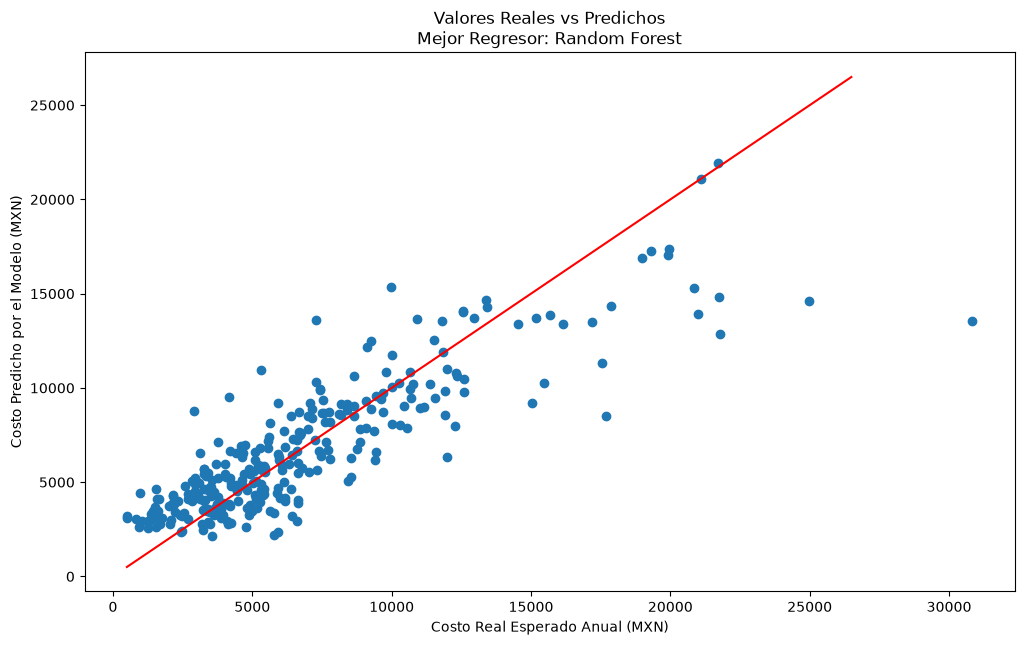

In [27]:
mejor_modelo_nombre = comparacion_regresion_val.index[0]
mejor_pipeline = regresion_pipelines[mejor_modelo_nombre]

y_pred_val = mejor_pipeline.predict(X_val)

plt.figure(figsize=(12, 7))
plt.scatter(x=y_reg_val, y=y_pred_val)

limite_max = max(y_reg_test.max(), y_pred_val.max())
limite_min = min(y_reg_test.min(), y_pred_val.min())
plt.plot([limite_min, limite_max], [limite_min, limite_max], color="red")

plt.title(f"Valores Reales vs Predichos\nMejor Regresor: {mejor_modelo_nombre}")
plt.xlabel("Costo Real Esperado Anual (MXN)")
plt.ylabel("Costo Predicho por el Modelo (MXN)")
plt.show()

Tabla de comparación de métricas en validación:


,MAE,RMSE,R2,RSE
Regresión Lineal,1760.2857,2311.2225,0.7597,2599.4393
Regresión Lasso,1758.9170,2311.5935,0.7596,2599.8566


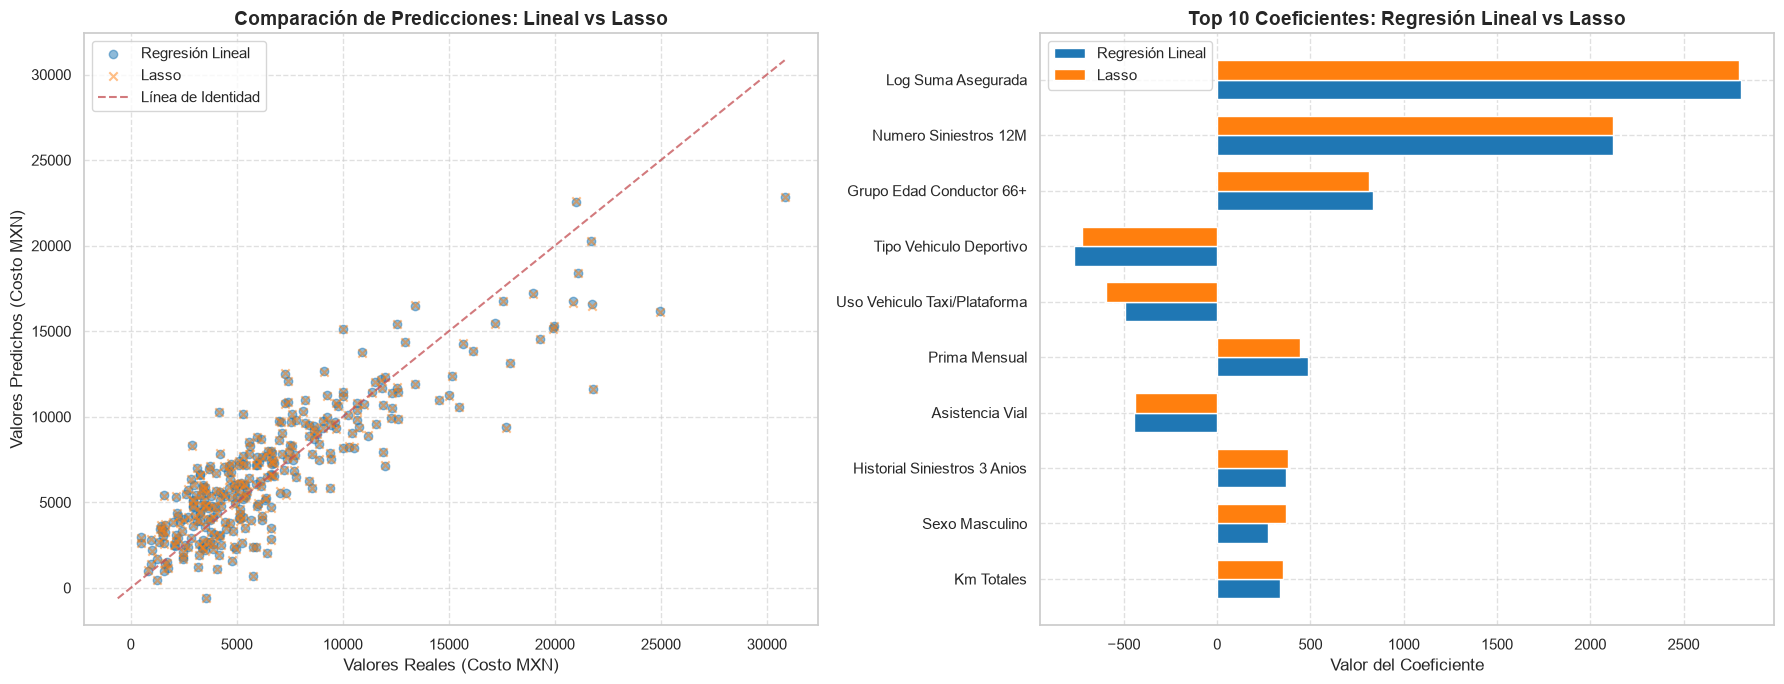

In [28]:
# REGRESIÓN LINEAL VS LASSO

# 1. Obtener y entrenar modelos (asegurando robustez si se ejecuta de forma aislada)
lr_model = regresion_pipelines.get("Regresión lineal")
lasso_model = regresion_pipelines.get("Lasso")

if lr_model is None or lasso_model is None:
    raise ValueError(
        "Ejecute el código completo para entrenar los modelos necesarios"
    )

# 2. Generar predicciones en el conjunto de validación
pred_lr = lr_model.predict(X_val)
pred_lasso = lasso_model.predict(X_val)

# 3. Calcular métricas completas (incluyendo RSE)
def calcular_metricas_completas(y_real, y_pred, pipeline):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    
    # RSE (Residual Standard Error)
    n = len(y_real)
    features_count = len(nombres_features(pipeline))
    p = features_count + 1  # Parámetros (coeficientes + intercepto)
    rse = np.sqrt(np.sum((y_real - y_pred)**2) / (n - p))
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "RSE": rse}

metrics_lr = calcular_metricas_completas(y_reg_val, pred_lr, lr_model)
metrics_lasso = calcular_metricas_completas(y_reg_val, pred_lasso, lasso_model)

# Crear tabla comparativa
df_comparacion = pd.DataFrame({
    "Regresión Lineal": metrics_lr,
    "Regresión Lasso": metrics_lasso
}).T

print("Tabla de comparación de métricas en validación:")
display(df_comparacion.round(4))

# 4. Obtener coeficientes y limpiar nombres para graficar
features_names = nombres_features(lr_model)
coefs_lr = lr_model.named_steps["model"].coef_
coefs_lasso = lasso_model.named_steps["model"].coef_

# Limpieza de nombres de variables para mejor presentación
clean_names = []
for name in features_names:
    clean = name.split("__")[-1]
    clean = clean.replace("_mxn", "").replace("_", " ").title()
    clean_names.append(clean)

df_coefs = pd.DataFrame({
    "Variable Original": features_names,
    "Variable": clean_names,
    "Regresión Lineal": coefs_lr,
    "Lasso": coefs_lasso
})

# 5. Generar Gráficos
# Configurar estilo 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Comparación de Predicciones vs Reales
axes[0].scatter(y_reg_val, pred_lr, alpha=0.5, label="Regresión Lineal", color="#1f77b4")
axes[0].scatter(y_reg_val, pred_lasso, alpha=0.5, label="Lasso", color="#ff7f0e", marker="x")
lims = [
    min(y_reg_val.min(), pred_lr.min(), pred_lasso.min()),
    max(y_reg_val.max(), pred_lr.max(), pred_lasso.max())
]
axes[0].plot(lims, lims, 'r--', alpha=0.75, zorder=3, label="Línea de Identidad")
axes[0].set_xlabel("Valores Reales (Costo MXN)", fontsize=12)
axes[0].set_ylabel("Valores Predichos (Costo MXN)", fontsize=12)
axes[0].set_title("Comparación de Predicciones: Lineal vs Lasso", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.6)

# Gráfico 2: Importancia de Variables (Coeficientes con mayor magnitud en Lasso)
# Seleccionamos las 10 variables con mayor coeficiente absoluto en Lasso
top_coefs = df_coefs.reindex(df_coefs["Lasso"].abs().sort_values(ascending=False).index).head(10)
top_coefs_sorted = top_coefs.sort_values(by="Lasso", key=abs)

# Graficar coeficientes comparativos
x_pos = np.arange(len(top_coefs_sorted))
width = 0.35

axes[1].barh(x_pos - width/2, top_coefs_sorted["Regresión Lineal"], width, label="Regresión Lineal", color="#1f77b4")
axes[1].barh(x_pos + width/2, top_coefs_sorted["Lasso"], width, label="Lasso", color="#ff7f0e")
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(top_coefs_sorted["Variable"], fontsize=11)
axes[1].set_xlabel("Valor del Coeficiente", fontsize=12)
axes[1].set_title("Top 10 Coeficientes: Regresión Lineal vs Lasso", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


### Interpretación de cinco coeficientes (Regresión Lineal y Lasso)

Al analizar los coeficientes obtenidos por la **Regresión Lineal** y la **Regresión Lasso**, podemos interpretar la relación lineal de las variables predictoras con el costo esperado anual en pesos mexicanos (`costo_esperado_anual_mxn`). A continuación, se detallan cinco de las variables más importantes en términos de impacto:

1. **Uso de Vehículo: Taxi/Plataforma (`uso_vehiculo_Taxi/Plataforma`)**
   * **Coeficiente:** (-) Negativo
   * **Interpretación:** Aunque nuestro sentido común nos dice que los vehículos de uso comercial (como la moto de Mario, taxis o plataformas de transporte como Uber/DiDi) tienen una exposición al riesgo mucho mayor debido al tiempo prolongado de circulación, el modelo le asigna un coeficiente negativo. Esto puede ocurrir porque el alto riesgo de estos vehículos ya está fuertemente penalizado y absorbido por la variable de la prima mensual (`prima_mensual_mxn`), la cual tiene tarifas mucho más altas en comparación a las demás. Suponemos que el coeficiente negativo actúa entonces como un factor de "ajuste" para evitar que el modelo sobreestime el costo anual.

2. **Suma Asegurada Logarítmica (`log_suma_asegurada`)**
   - **Coeficiente:** (+) Postitivo 
   - **Interpretación:** Este coeficiente positivo indica que los vehículos con una mayor suma asegurada (es decir, de mayor valor comercial) están asociados con un incremento considerable en el costo esperado anual. Desde una perspectiva actuarial, es lógico que asegurar activos más costosos implique reclamos promedio de mayor severidad en caso de siniestro total o parcial.

3. **Historial de Siniestros Recientes (`siniestros_en_12m`)**
   - **Coeficiente:** (+) Positivo 
   - **Interpretación:** La presencia de al menos un siniestro en los últimos 12 meses tiene un impacto altamente positivo en la predicción del costo esperado anual. Los asegurados que ya han registrado accidentes recientemente representan un riesgo agravado (alta frecuencia de reclamos), lo cual eleva directamente el costo técnico estimado de la póliza para el periodo actual.

4. **Conductor Adulto Mayor (`grupo_edad_conductor_66+`)**
   * **Coeficiente:** (+) Positivo
   * **Interpretación:** Este coeficiente altamente positivo nos indica que los conductores pertenecientes al grupo de edad de 66 años o más presentan un costo esperado sustancialmente superior en comparación con el grupo de edad de referencia. Esto se alinea con la teoría del riesgo en seguros, donde los conductores de edad avanzada suelen mostrar una mayor vulnerabilidad física y tiempos de reacción alterados, incrementando la siniestralidad esperada.

5. **Tipo de Vehículo: Deportivo (`tipo_vehiculo_Deportivo`)**
   - **Coeficiente:** (-) Negativo 
   - **Interpretación:** Curiosamente, el coeficiente asociado a vehículos deportivos es negativo. Esto indica que, *manteniendo constantes las demás variables* (como la prima mensual y el historial de siniestros), el hecho de ser un vehículo deportivo se asocia con un menor costo esperado en este modelo lineal. Actuarialmente, esto suele ser un efecto de multicolinealidad con la prima mensual (`prima_mensual_mxn`), que ya captura de forma positiva gran parte del riesgo inherente a estos autos (los cuales suelen tener primas sumamente elevadas), actuando este coeficiente como una corrección en el ajuste lineal multivariado.

### 4.3 Entrenamiento de Modelos de Clasificación

Evaluación de clasificadores aplicados a la variable lógica `riesgo_alto`. Los algoritmos basados en árboles de decisión no requieren escalamiento ni estandarización previa de variables numéricas.

In [29]:
modelos_clasificacion = {
    "Dummy prior": (DummyClassifier(strategy = "prior"), False),
    "Logística balanceada": (LogisticRegression(class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE), True),
    "Árbol balanceado": (DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, class_weight='balanced', random_state=RANDOM_STATE), False),
    "Random Forest balanceado": (RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state = RANDOM_STATE), False)
}

clas_pipelines_validacion = {}
filas = []

for nombre, (modelo, escalar) in modelos_clasificacion.items():
    pipe = crear_pipeline(modelo, escalar_numericas = escalar) 
    pipe.fit(X_train, y_clas_train)
    prob_val = extraer_proba(pipe, X_val)
    metricas = metricas_clasificacion(y_clas_val, prob_val, umbral=0.50)
    filas.append({'modelo': nombre, **metricas})
    clas_pipelines_validacion[nombre] = pipe

comparacion_clasificacion_val = pd.DataFrame(filas).set_index('modelo').sort_values('F1', ascending=False)
display(comparacion_clasificacion_val.round(4))

,accuracy,precision,recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
modelo,,,,,,,,,,
Gradient Boosting,0.9257,0.8065,0.6098,0.6944,0.9524,0.7790,249,6,16,25
Logística balanceada,0.8615,0.5000,0.8780,0.6372,0.9442,0.8008,219,36,5,36
Árbol balanceado,0.8716,0.5254,0.7561,0.6200,0.9008,0.7042,227,28,10,31
Random Forest balanceado,0.9088,0.7692,0.4878,0.5970,0.9511,0.7805,249,6,21,20
Dummy prior,0.8615,0.0000,0.0000,0.0000,0.5000,0.1385,255,0,41,0


### 4.4 Calibración del Umbral Óptimo de Decisión

Clasificador seleccionado con validación: Gradient Boosting
Criterio: Se maximizó F1 sujeto a recall >= 0.85.
Umbral elegido: 0.16

Umbrales ordenados por mejor F1-Score:


,umbral,accuracy,precision,recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
10,0.30,0.9358,0.7619,0.7805,0.7711,0.9524,0.779,245,10,9,32
9,0.28,0.9291,0.7174,0.8049,0.7586,0.9524,0.779,242,13,8,33
8,0.26,0.9257,0.7021,0.8049,0.7500,0.9524,0.779,241,14,8,33
12,0.34,0.9324,0.7838,0.7073,0.7436,0.9524,0.779,247,8,12,29
11,0.32,0.9291,0.7632,0.7073,0.7342,0.9524,0.779,246,9,12,29


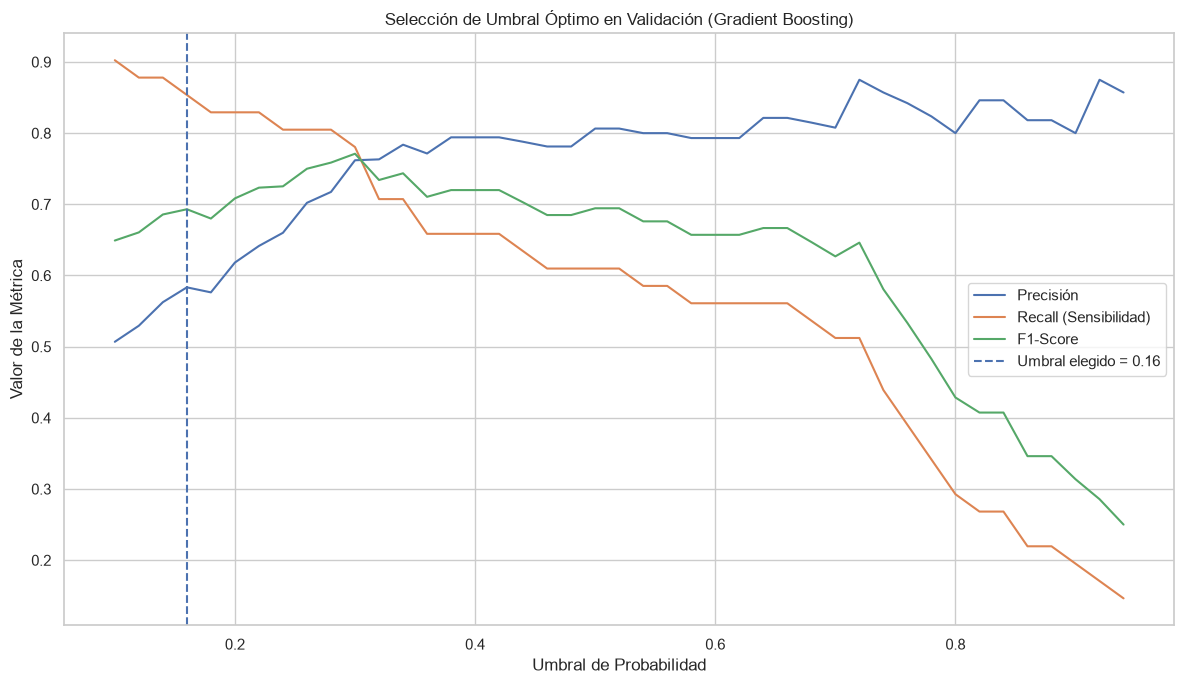

In [30]:
mejor_modelo_clas_nombre = comparacion_clasificacion_val.index[0]
mejor_pipeline_clas = clas_pipelines_validacion[mejor_modelo_clas_nombre]

prob_val = extraer_proba(mejor_pipeline_clas, X_val)

RECALL_MINIMO = 0.85
umbrales = np.round(np.arange(0.10, 0.95, 0.02), 2)
filas_umbral = []

for umbral in umbrales:
    filas_umbral.append({'umbral': umbral, **metricas_clasificacion(y_clas_val, prob_val, umbral)})

tabla_umbrales = pd.DataFrame(filas_umbral)

candidatos_umbral = tabla_umbrales.loc[tabla_umbrales['recall'] >= RECALL_MINIMO]

if candidatos_umbral.empty:
    fila_umbral = tabla_umbrales.sort_values(['F1', 'recall'], ascending=False).iloc[0]
    criterio_umbral = "No se alcanzó el recall mínimo. Se eligió por F1."
else:
    fila_umbral = candidatos_umbral.sort_values(['F1', 'precision'], ascending=False).iloc[0]
    criterio_umbral = f"Se maximizó F1 sujeto a recall >= {RECALL_MINIMO:.2f}."

umbral_elegido = float(fila_umbral['umbral'])

print('Clasificador seleccionado con validación:', mejor_modelo_clas_nombre)
print('Criterio:', criterio_umbral)
print('Umbral elegido:', umbral_elegido)
print('\nUmbrales ordenados por mejor F1-Score:')
display(tabla_umbrales.sort_values('F1', ascending=False).head().round(4))

plt.figure(figsize = (12, 7))
plt.plot(tabla_umbrales['umbral'], tabla_umbrales['precision'], label='Precisión')
plt.plot(tabla_umbrales['umbral'], tabla_umbrales['recall'], label='Recall (Sensibilidad)')
plt.plot(tabla_umbrales['umbral'], tabla_umbrales['F1'], label='F1-Score')
plt.axvline(umbral_elegido, linestyle='--', label=f'Umbral elegido = {umbral_elegido:.2f}')

plt.title(f'Selección de Umbral Óptimo en Validación ({mejor_modelo_clas_nombre})')
plt.xlabel('Umbral de Probabilidad')
plt.ylabel('Valor de la Métrica')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

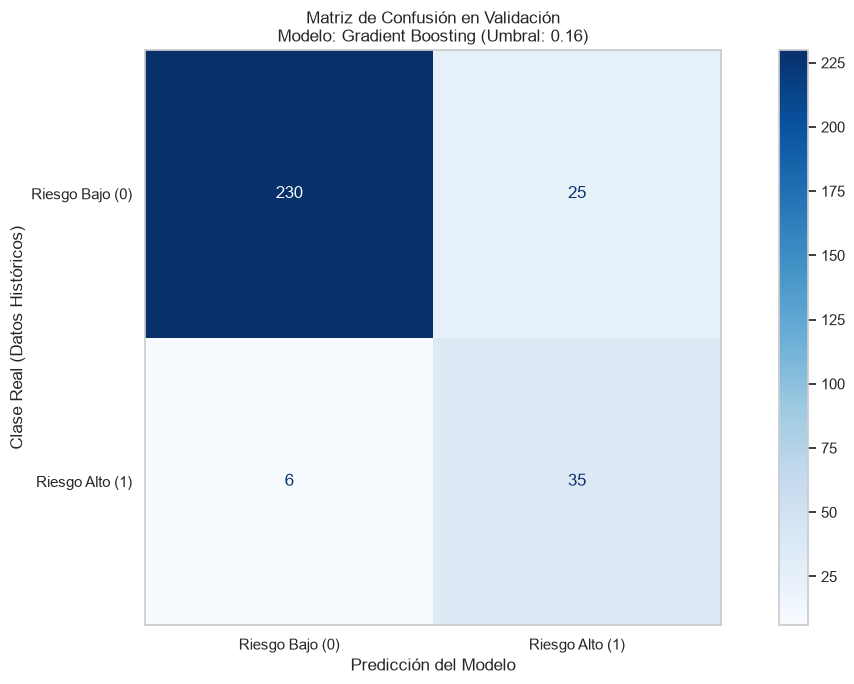

In [31]:
y_pred_val_umbral = (prob_val >= umbral_elegido).astype(int)

cm = confusion_matrix(y_clas_val, y_pred_val_umbral)

fig, ax = plt.subplots(figsize=(12, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Riesgo Bajo (0)', 'Riesgo Alto (1)']
)

disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title(f"Matriz de Confusión en Validación\nModelo: {mejor_modelo_clas_nombre} (Umbral: {umbral_elegido:.2f})")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real (Datos Históricos)")
ax.grid()

plt.tight_layout()
plt.show()

### 4.5 Reducción de Dimensionalidad mediante PCA

> **PCA:** (Análisis de Componentes Principales) técnica estadística y de Machine Learning no supervisado utilizada para reducir la dimensionalidad de un conjunto de datos. Simplifica bases de datos complejas con muchas variables a un número menor, conservando la mayor cantidad de información posible.

Con el propósito de explorar agrupamientos subyacentes e inspeccionar la distribución espacial de las observaciones se aplica un análisis de componentes principales (PCA):
* Se utiliza la matriz de características preprocesadas.
* Se proyectan los datos sobre las dos componentes principales de mayor varianza.
* Se grafican las observaciones etiquetadas por `riesgo_alto` y `clase_costo`.
* Se determina el nivel de varianza explicada acumulada y la capacidad del PCA para segregar espacialmente los niveles de riesgo.

In [32]:
pipeline_pca = Pipeline([
    ("feature engineering", ActuarialFeatureEngineer()),
    ("preprocesado", crea_preprocesador(escalar_numericas = True))
])

X_train_red = pipeline_pca.fit_transform(X_train)
X_val_red = pipeline_pca.transform(X_val)
X_test_red = pipeline_pca.transform(X_test)

pca = PCA(n_components = 2, random_state = RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_red)
X_val_pca = pca.transform(X_val_red)
X_test_pca = pca.transform(X_test_red)

idx_pca = list(id_train) + list(id_val) + list(id_test
                                               )
df_pca = pd.DataFrame(np.vstack([X_train_pca, X_val_pca, X_test_pca]),
                      columns = ["PC1", "PC2"],
                      index = idx_pca)

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza total explicada", pca.explained_variance_ratio_.sum())

df_pca["riesgo_alto"] = df.loc[df_pca.index, "riesgo_alto"].values
df_pca["clase_costo"] = df.loc[df_pca.index, "clase_costo"].values

Varianza explicada por cada componente: [0.12669392 0.07086588]
Varianza total explicada 0.19755980142593443


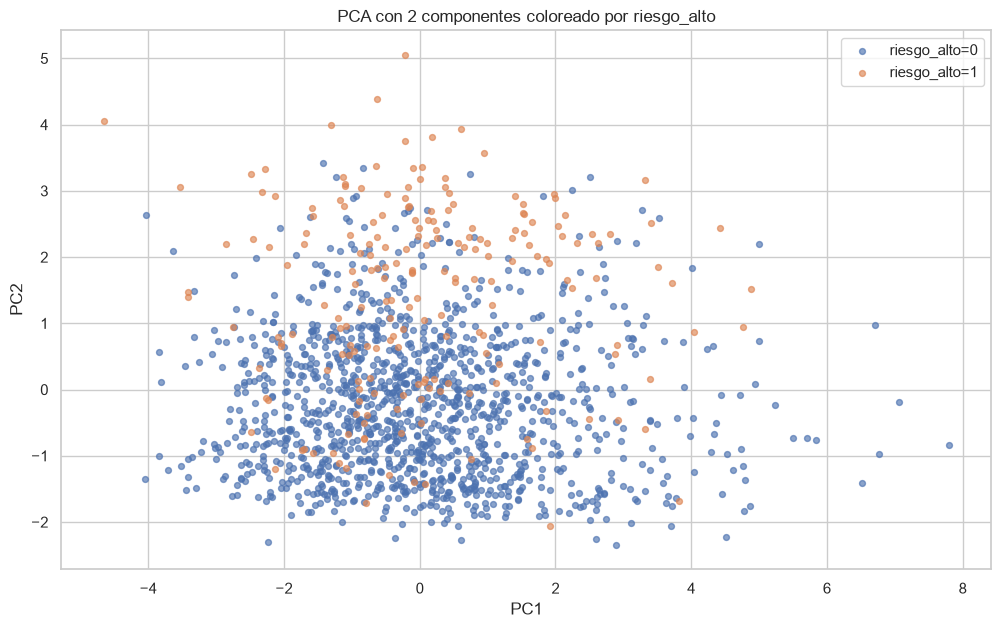

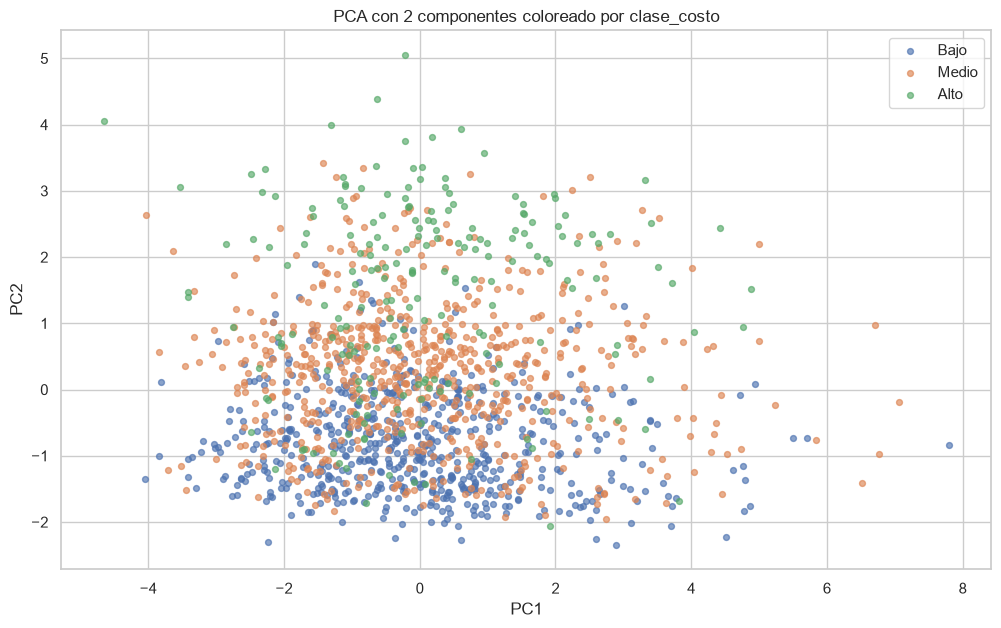

In [33]:
plt.figure(figsize=(12, 7))
for clase in sorted(df_pca['riesgo_alto'].unique()):
    subset = df_pca[df_pca['riesgo_alto'] == clase]
    plt.scatter(subset['PC1'], subset['PC2'], s=18, alpha=0.65, label=f'riesgo_alto={clase}')
plt.title('PCA con 2 componentes coloreado por riesgo_alto')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

plt.figure(figsize=(12, 7))
for clase in ['Bajo', 'Medio', 'Alto']:
    subset = df_pca[df_pca['clase_costo'] == clase]
    plt.scatter(subset['PC1'], subset['PC2'], s=18, alpha=0.65, label=clase)
plt.title('PCA con 2 componentes coloreado por clase_costo')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

La varianza explicada representa la proporción de la variabilidad original retenida por los componentes principales construivos (PC1 y PC2), es decir, el porcentaje qué porcentaje de la información original logró "sobrevivir al ser "compactada" en los dos componentes, que para nuestro caso fue:

`Varianza explicada por cada componente: [0.12513633,  0.07365612]`

`Varianza total explicada 0.198792455343819`

* **Interpretación:** En este análisis, la proyección bidimensional mediante PCA no permite segregar o aislar visualmente clases diferenciables de riesgo. La superposición de clases en el gráfico bidimensional sugiere que el límite de decisión óptimo es no lineal y de carácter multidimensional, requiriendo modelos clasificadores más avanzados.

### 4.6 Evaluación de Rendimiento General (Conjunto de Prueba)

Se evalúa el mejor estimador de regresión y el mejor modelo clasificador (calibrado con el umbral óptimo obtenido en validación) utilizando de forma exclusiva el conjunto de prueba independiente para estimar el desempeño real en producción.

,MAE,RMSE,R2
Random Forest,1688.747188,2606.0612,0.678564


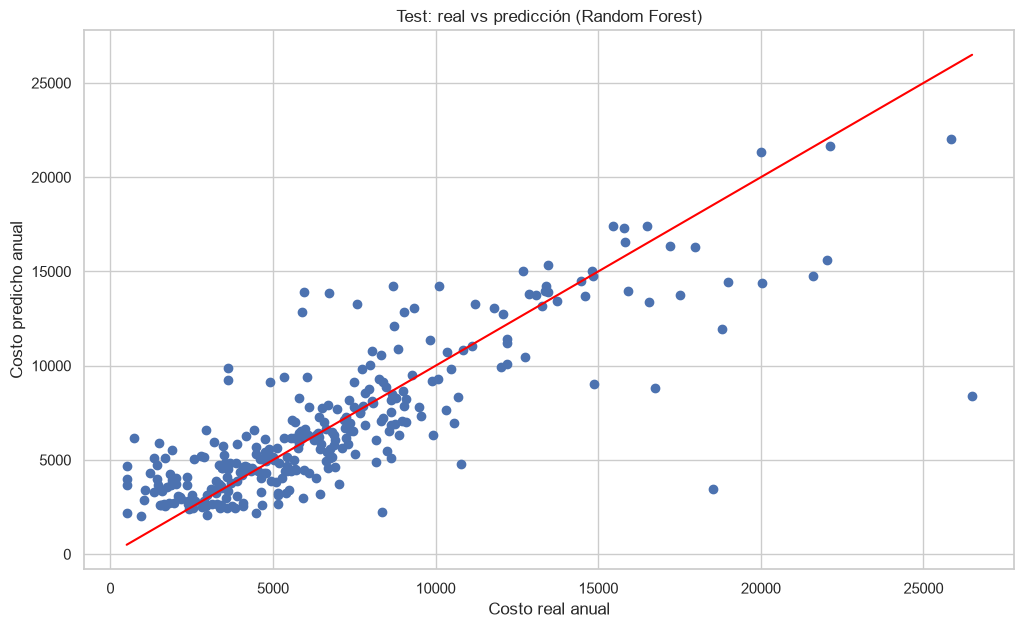

In [34]:
pred_reg_test = mejor_pipeline.predict(X_test)
metricas_reg_test = metricas_regresion(y_reg_test, pred_reg_test)
display(pd.DataFrame([metricas_reg_test], index = [mejor_modelo_nombre]))

plt.figure(figsize = (12, 7))
plt.scatter(y_reg_test, pred_reg_test)
lim_min = min(y_reg_test.min(), pred_reg_test.min())
lim_max = max(y_reg_test.max(), pred_reg_test.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], label = "Predicción", color = "red")
plt.title(f"Test: real vs predicción ({mejor_modelo_nombre})")
plt.xlabel("Costo real anual")
plt.ylabel("Costo predicho anual")

plt.show()

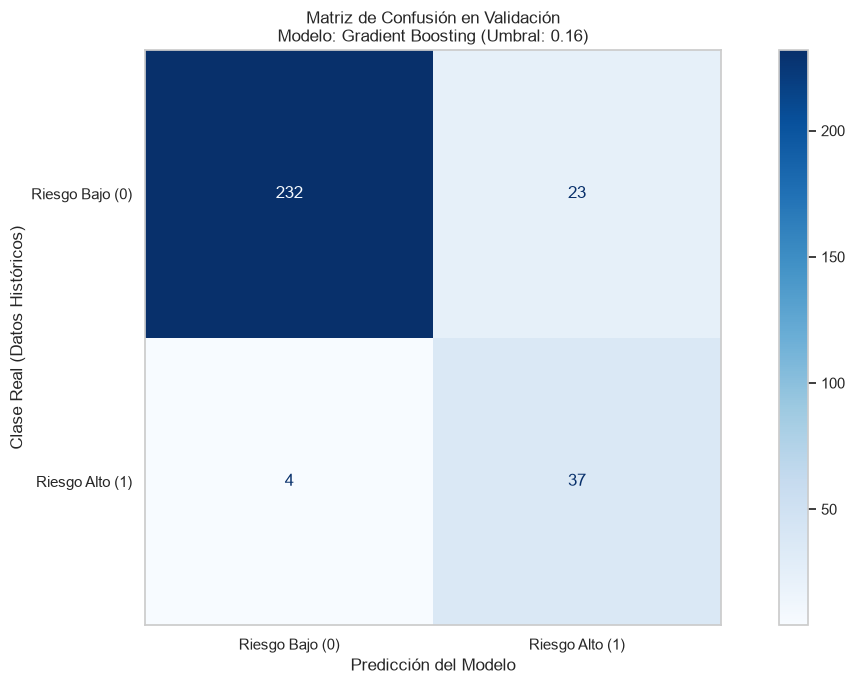

In [35]:
prob_test = extraer_proba(mejor_pipeline_clas, X_test)

y_pred_test_umbral = (prob_test >= umbral_elegido).astype(int)

cm = confusion_matrix(y_clas_test, y_pred_test_umbral)

fig, ax = plt.subplots(figsize=(12, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Riesgo Bajo (0)', 'Riesgo Alto (1)']
)

disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title(f"Matriz de Confusión en Validación\nModelo: {mejor_modelo_clas_nombre} (Umbral: {umbral_elegido:.2f})")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real (Datos Históricos)")
ax.grid()

plt.tight_layout()
plt.show()

#### Reporte de Métricas Finales de Desempeño

In [36]:
metricas_clas_test = metricas_clasificacion(
    y_clas_test,
    prob_test,
    umbral=umbral_elegido
)

display(
    pd.DataFrame([metricas_clas_test], index=[mejor_modelo_clas_nombre]).round(4)
)

,accuracy,precision,recall,F1,ROC_AUC,PR_AUC,TN,FP,FN,TP
Gradient Boosting,0.9088,0.6167,0.9024,0.7327,0.9562,0.8474,232,23,4,37


## 5. Interpretación de Parámetros e Importancia de Atributos

Análisis e interpretación de los coeficientes obtenidos por los modelos lineales y de las importancias relativas calculadas por el modelo Random Forest, junto con un diagnóstico de posibles sesgos predictivos.

<Axes: title={'center': 'Importancia de las variables (Gradient Boosting)'}, ylabel='feature'>

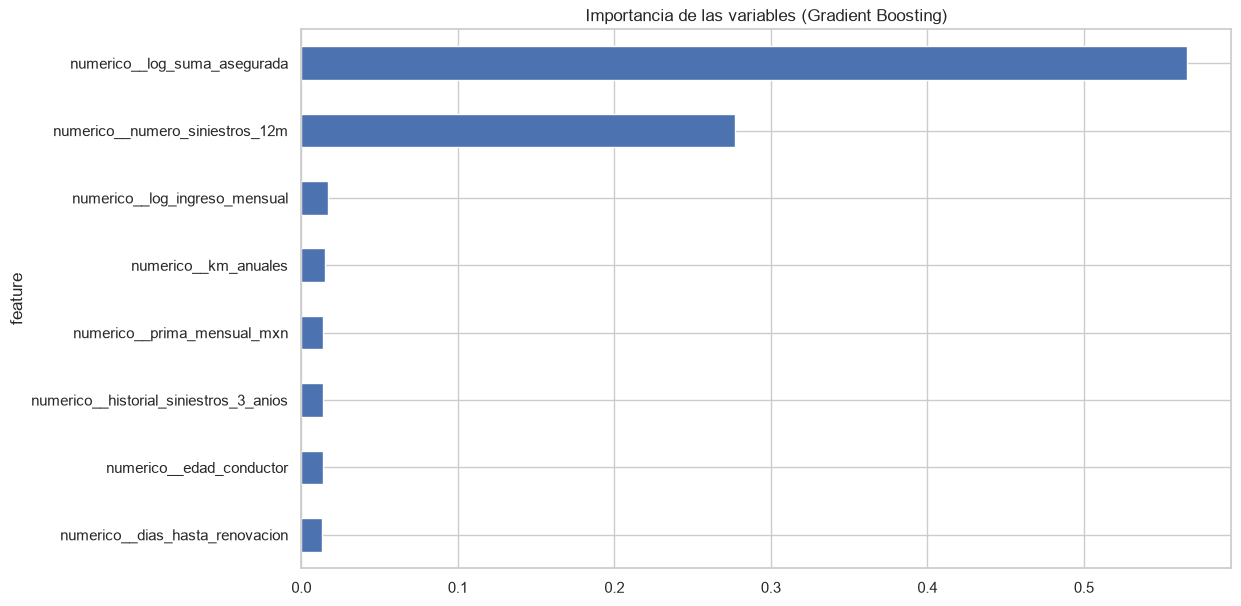

In [37]:
xgb_reg = regresion_pipelines.get("Gradient Boosting")
features_xgb = nombres_features(xgb_reg)
coefi = xgb_reg.named_steps["model"].feature_importances_
coef_df = pd.DataFrame({
    "feature": features_xgb,
    "coeficiente": coefi
})

coef_df.set_index("feature")["coeficiente"].sort_values().tail(8).plot(
    kind = "barh", 
    figsize = (12, 7), 
    title = "Importancia de las variables (Gradient Boosting)"
)


### 5.1 Importancia de Atributos en Random Forest (Regresión)

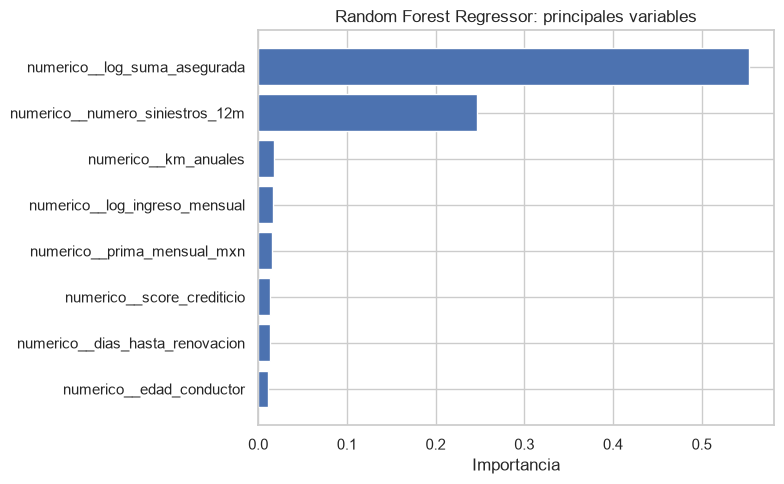

In [38]:
rf_reg_pipe = regresion_pipelines.get('Random Forest')
nombres_features_rf_reg = nombres_features(rf_reg_pipe)
importancias_rf_reg = rf_reg_pipe.named_steps['model'].feature_importances_
importancias_reg_df = pd.DataFrame({'feature': nombres_features_rf_reg, 'importance': importancias_rf_reg}).sort_values('importance', ascending=False)
importancias_reg_df.to_csv(OUTPUTS_DIR / 'importancias_rf_regresion.csv', index=False)
plt.figure(figsize=(8, 5))
top_imp = importancias_reg_df.head(8).sort_values('importance')
plt.barh(top_imp['feature'], top_imp['importance'])
plt.title('Random Forest Regressor: principales variables')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

#### 5.1.1 Análisis e interpretación de las variables principales

A diferencia de un modelo lineal rural y silvestre, el Random Forest no nos da coeficientes positivos o negativos, sino que nos dice qué tan "útil" fue cada variable para reducir la incertidumbre en nuestras predicciones. 

Viendo la gráfica, es muy evidente que el modelo basa casi todas sus conclusiones en un **Top 3** muy marcado, dejando al resto de las variables digamos como simples ajustes:

1. **La Suma Asegurada (`log_suma_asegurada`):** 
   De nuevo vuelve a aparecer esta variable, llevándose más del 50% de la importancia total. Esto como se mencionó con anterioridad, es lógico pues es el tope máximo de lo que la aseguradora va a tener que pagar en caso de un siniestro grave (como pérdida total o robo total), aunque depende del valor del vehículo.

2. **El peso del historial (`numero_siniestros_12m` y `siniestros_en_12m`):**
   El segundo y tercer lugar se lo llevan las variables relacionadas con la siniestralidad reciente. Como en la mayoria de los fenómenos el mejor predictor de un accidente futuro, es un accidente pasado. Si el cliente ya tuvo accidentes en los últimos 12 meses, el algoritmo lo perfila de inmediato como un riesgo más costoso.

3. **Las variables de ajuste (`km_anuales`, `ingreso_mensual`, `score_crediticio`, etc.):**
   Del cuarto lugar para abajo, la importancia cae bastante, por debajo del 3%. Cosas que por lógica creeríamos que impactan mucho (como los kilómetros que manejan al año, sus ingresos o su historial crediticio), realmente solo le sirven al modelo para hacer micro-ajustes en la predicción final. En resumen: a nuestro modelo le importa mucho más **qué auto tienes y si ya chocaste**, que cuánto ganas o qué tan seguido sales a manejar.


### 5.2 Importancia de Atributos en Random Forest (Clasificación)

,feature,importance
12,numerico__log_suma_asegurada,0.176568
10,numerico__numero_siniestros_12m,0.159627
57,ordinal__segmento_marca,0.118459
3,numerico__prima_mensual_mxn,0.075226
8,numerico__dias_hasta_renovacion,0.034789
11,numerico__log_ingreso_mensual,0.034377
9,numerico__puntaje_riesgo_zona,0.034087
13,numerico__km_totales,0.031204
1,numerico__antiguedad_cliente_anios,0.029270
6,numerico__km_anuales,0.028044


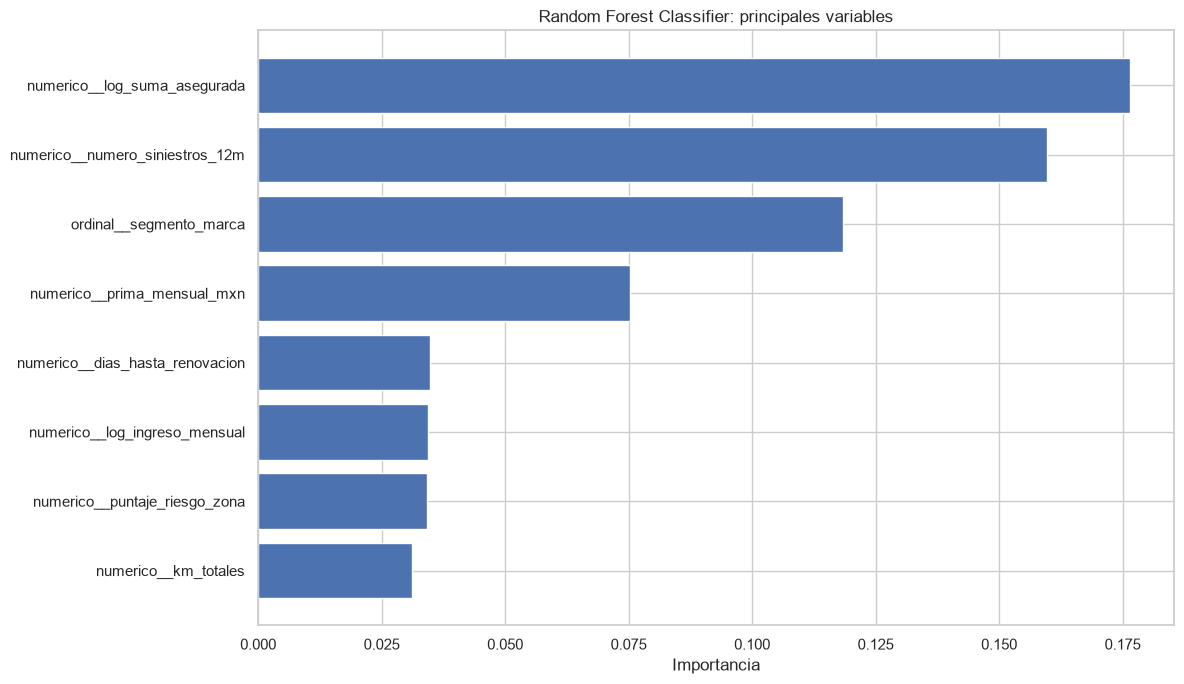

In [39]:
rf_clas_pipe = clas_pipelines_validacion.get('Random Forest balanceado')
nombres_features_rf_clas = nombres_features(rf_clas_pipe)
coef_rf_clas = rf_clas_pipe.named_steps['model'].feature_importances_
coef_clas_df = pd.DataFrame({'feature': nombres_features_rf_clas, 'importance': coef_rf_clas}).sort_values('importance', ascending=False)
display(coef_clas_df.head(15))
coef_clas_df.to_csv(OUTPUTS_DIR / 'importancias_rf_clasificacion.csv', index=False)
plt.figure(figsize=(12, 7))
top_imp_clf = coef_clas_df.head(8).sort_values('importance')
plt.barh(top_imp_clf['feature'], top_imp_clf['importance'])
plt.title('Random Forest Classifier: principales variables')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

#### 5.2.1 Análisis e interpretación de las variables principales  ("Alto Riesgo" - Random Forest Classifier)

Así como en el modelo de regresión intentábamos adivinar cuanto nos iba a costar un siniestro, aquí el objetivo es etiquetar al cliente como **"Riesgo Alto"** o **"Riesgo Normal"**. Viendo la gráfica de importancia de variables, notamos que a diferencia del modelo de costos,  el modelo de clasificación reparte mucho más el peso entre varias características:

1. **La Suma Asegurada (`log_suma_asegurada`):** 
  Un auto más caro tiene más probabilidad de caer en la categoría de "alto riesgo" simplemente porque cualquier daño que sufra será mucho más caro de reparar.

2. **El historial (`numero_siniestros_12m` y `siniestros_en_12m`):**
   La hisoria se repite tambien con estas dos, saber si el cliente chocó en el último año y cuántas veces lo hizo, en conjunto, suma más del 23% de importancia.

3. **Fabricación, calidad, etc (`segmento_marca`):**
   A diferencia del de regresión, aquí el segmento de la marca del auto cobra mucho peso (casi 10%). Esto nos dice que estadísticamente hay ciertas marcas o segmentos (por ejemplo, autos deportivos, de lujo o los más robados del país) que por sí solos representan un mayor riesgo para la aseguradora, y esto lo vemos naturalmente en la vida cotitidana, sectores como los carros de lujo, o al contrario vehículos de entrada (veamos los nuevos carros electricos) de ciertas marcas.

4. **La Prima Mensual (`prima_mensual_mxn`):**
   Se lleva el cuarto puesto. Básicamente, si el cliente ya está pagando una tarifa muy alta, el modelo lo usa como una pista fuerte de que, efectivamente, pertenece a un segmento de mayor riesgo desde el inicio. Si pagas una prima alta es porque parcialmente tu suma es alta, y eso representa un indicio de mayor riesgo.

## 6. Serialización y Almacenamiento de Modelos (joblib)

Esta celda toma nuestros modelos ya entrenados y los guarda en archivos locales junto con sus métricas, dejándolos listos para la `app.py`.

In [40]:
import unicodedata


def limpiar_nombre(nombre):
    nombre = unicodedata.normalize("NFKD", nombre).encode("ascii", "ignore").decode("utf-8")
    nombre = nombre.lower().replace(" ", "_")
    return "".join(caracter for caracter in nombre if caracter.isalnum() or caracter == "_")


modelos_exportados = []

for nombre, pipeline in regresion_pipelines.items():
    nombre_archivo = f"regresion_{limpiar_nombre(nombre)}.joblib"
    ruta_modelo = MODELS_DIR / nombre_archivo
    joblib.dump(pipeline, ruta_modelo)

    modelos_exportados.append({
        "tipo": "regresion",
        "modelo": nombre,
        "archivo": nombre_archivo
    })


for nombre, pipeline in clas_pipelines_validacion.items():
    nombre_archivo = f"clasificacion_{limpiar_nombre(nombre)}.joblib"
    ruta_modelo = MODELS_DIR / nombre_archivo
    joblib.dump(pipeline, ruta_modelo)

    modelos_exportados.append({
        "tipo": "clasificacion",
        "modelo": nombre,
        "archivo": nombre_archivo
    })


joblib.dump(mejor_pipeline, MODELS_DIR / "mejor_modelo_regresion.joblib")
joblib.dump(mejor_pipeline_clas, MODELS_DIR / "mejor_modelo_clasificacion.joblib")

metadata_modelos = {
    "mejor_modelo_regresion": mejor_modelo_nombre,
    "mejor_modelo_clasificacion": mejor_modelo_clas_nombre,
    "umbral_clasificacion": float(umbral_elegido),
    "modelos_exportados": modelos_exportados
}

with open(MODELS_DIR / "metadata_modelos.json", "w", encoding="utf-8") as archivo:
    json.dump(metadata_modelos, archivo, indent=4, ensure_ascii=False)

comparacion_regresion_val.to_csv(OUTPUTS_DIR / "comparacion_modelos_regresion.csv")
comparacion_clasificacion_val.to_csv(OUTPUTS_DIR / "comparacion_modelos_clasificacion.csv")

print("Modelos exportados en:", MODELS_DIR)
display(pd.DataFrame(modelos_exportados))

Modelos exportados en: c:\Users\PC\OneDrive\Documentos\GitHub\proyecto_seguro_actuarial\models


,tipo,modelo,archivo
0,regresion,Dummy mediana,regresion_dummy_mediana.joblib
1,regresion,Regresión lineal,regresion_regresion_lineal.joblib
2,regresion,Ridge,regresion_ridge.joblib
3,regresion,Lasso,regresion_lasso.joblib
4,regresion,Árbol,regresion_arbol.joblib
5,regresion,Random Forest,regresion_random_forest.joblib
6,regresion,Gradient Boosting,regresion_gradient_boosting.joblib
7,clasificacion,Dummy prior,clasificacion_dummy_prior.joblib
8,clasificacion,Logística balanceada,clasificacion_logistica_balanceada.joblib
9,clasificacion,Árbol balanceado,clasificacion_arbol_balanceado.joblib
